In [4]:
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.utils import resample
from sklearn.feature_selection import f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

# Настройки
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
class LabAnalyzer:
    """
    Класс-обертка для анализа датасета. 
    Позволяет инкапсулировать логику и сохранять состояние.
    """
    def __init__(self, df, target_col='target'):
        self.df = df
        self.target_col = target_col
        self.feature_cols = [c for c in df.columns if c != target_col]

    @staticmethod
    def generate_dataset(n_samples=3000, n_features=16, random_state=42):
        """
        Генерация датасета с заданными свойствами:
        - 3 класса (по 1000 объектов)
        - 2 класса перекрываются, 1 отдален
        - Признаки коррелируют
        """
        np.random.seed(random_state)
        
        # 1. Определяем центры кластеров
        # Два центра рядом (перекрытие), один далеко
        centers = [
            np.zeros(n_features),              # Класс 0
            np.ones(n_features) * 1.5,         # Класс 1 (близко к 0, будет перекрытие)
            np.ones(n_features) * 10.0         # Класс 2 (далеко)
        ]
        
        # 2. Генерируем "сырые" блобы (они сферические и нескоррелированные)
        X, y = make_blobs(n_samples=n_samples, centers=centers, n_features=n_features, 
                          cluster_std=[3.0, 3.0, 2.0], random_state=random_state)
        
        # 3. Добавляем корреляции (вращаем пространство)
        # Умножаем на случайную матрицу, чтобы признаки перестали быть независимыми
        transformation_matrix = np.random.normal(size=(n_features, n_features))
        X_correlated = np.dot(X, transformation_matrix)
        
        # Собираем в DataFrame
        cols = [f'feature_{i+1}' for i in range(n_features)]
        df = pd.DataFrame(X_correlated, columns=cols)
        df['target'] = y
        
        return df

    def get_report(self):
        """Выводит табличный отчет о характеристиках датасета"""
        
        stats = {
            "Характеристика": [
                "Размерность датасета (Rows, Cols)",
                "Количество признаков (X)",
                "Количество классов (y)",
                "Процент пропусков (NaN)",
                "Память (Memory usage)"
            ],
            "Значение": [
                self.df.shape,
                len(self.feature_cols),
                self.df[self.target_col].nunique(),
                f"{self.df.isna().mean().mean() * 100:.2f}%",
                f"{self.df.memory_usage(deep=True).sum() / 1024:.2f} KB"
            ]
        }
        
        display(Markdown("### Статистика по датасету"))
        display(pd.DataFrame(stats))
        
        display(Markdown("#### Распределение классов:"))
        class_counts = self.df[self.target_col].value_counts().reset_index()
        class_counts.columns = ['Класс', 'Количество']
        display(class_counts)

    def visualize_3d(self):
            """
            Интерактивная 3D визуализация.
            Использует PCA для сжатия признаков до 3-х главных компонент 
            с отображением объясненной дисперсии.
            """
            
            # 1. Применяем PCA
            pca = PCA(n_components=3)
            components = pca.fit_transform(self.df[self.feature_cols])
            
            # 2. Расчет объясненной дисперсии
            explained_variance = pca.explained_variance_ratio_ * 100
            
            # 3. Подготовка данных для Plotly с новыми лейблами
            pc_df = pd.DataFrame(components, columns=['PC1', 'PC2', 'PC3'])
            pc_df[self.target_col] = self.df[self.target_col].astype(str)
            
            # Создание информативных лейблов для осей
            labels = {
                'PC1': f'PC1 ({explained_variance[0]:.2f}% дисперсии)',
                'PC2': f'PC2 ({explained_variance[1]:.2f}% дисперсии)',
                'PC3': f'PC3 ({explained_variance[2]:.2f}% дисперсии)',
                self.target_col: 'Класс'
            }
            
            # Общий заголовок
            total_explained = explained_variance.sum()
            title_text = (f'3D PCA Проекция Кластеров (Всего сохранено: {total_explained:.2f}% дисперсии)')

            # 4. Визуализация Plotly с улучшенным стилем
            fig = px.scatter_3d(
                pc_df, x='PC1', y='PC2', z='PC3',
                color=self.target_col,
                title=title_text,
                labels=labels,
                opacity=0.7,
                height=700,
                template='plotly_dark' # Улучшенный визуальный стиль
            )
            
            # Улучшение внешнего вида и интерактивности
            fig.update_traces(marker=dict(size=4, line=dict(width=0.5, color='DarkSlateGrey')))
            fig.update_layout(margin=dict(l=0, r=0, b=0, t=60), scene=dict(
                xaxis_title=labels['PC1'],
                yaxis_title=labels['PC2'],
                zaxis_title=labels['PC3']
            ))
            
            fig.show()

    def plot_correlations(self):
        """Матрица корреляций"""
        corr = self.df[self.feature_cols].corr()
        
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr, dtype=bool)) # Скрываем верхний треугольник для чистоты
        
        sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
                    vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
        plt.title('Матрица корреляций Пирсона')
        plt.show()

    def plot_distributions(self, n_features=7):
        """
        Визуализация распределений первых n признаков (PairPlot).
        Ограничиваем n, чтобы график не был слишком тяжелым.
        """
        subset_cols = self.feature_cols[:n_features] + [self.target_col]
        
        display(Markdown(f"### Распределения и связи первых {n_features} признаков"))
        
        # Используем pairplot для показа парных связей и распределений (диагональ)
        g = sns.pairplot(self.df[subset_cols], hue=self.target_col, 
                         palette="bright", corner=True, plot_kws={'alpha': 0.6})
        g.fig.suptitle(f'Pairplot для первых {n_features} признаков', y=1.02)
        plt.show()


In [6]:
class ImbalanceGenerator:
    """
    Класс для управления генерацией несбалансированных датасетов.
    """
    
    @staticmethod
    def create_imbalanced_versions(df, target_class, multipliers):
        """
        Генерирует словарь датасетов, ВКЛЮЧАЯ исходный (x1).
        """
        # --- ИЗМЕНЕНИЕ ЗДЕСЬ ---
        # Сразу добавляем оригинал под ключом 1
        datasets = {1: df.copy()} 
        
        df_target = df[df['target'] == target_class]
        df_others = df[df['target'] != target_class]
        
        print(f"Исходный размер класса {target_class}: {len(df_target)}")
        
        for m in multipliers:
            # Пропускаем 1, если он вдруг есть в списке multipliers, так как мы его уже добавили
            if m == 1:
                continue
                
            # Дублируем
            df_target_boosted = pd.concat([df_target] * m, ignore_index=True)
            df_new = pd.concat([df_others, df_target_boosted], ignore_index=True)
            
            # Перемешиваем
            df_new = df_new.sample(frac=1, random_state=42).reset_index(drop=True)
            
            datasets[m] = df_new
            
            print(f"Generated df{m}: Total rows = {len(df_new)}, Target Class Rows = {len(df_target_boosted)}")
            
        return datasets

    @staticmethod
    def visualize_imbalance_dynamics(datasets, original_df=None): # original_df теперь опционален
        """
        Интерактивная визуализация динамики.
        """
        data = []
        
        # Теперь просто проходимся по всем датасетам в словаре
        # Сортируем ключи, чтобы график был по порядку (1, 2, 5...)
        for m in sorted(datasets.keys()):
            df = datasets[m]
            counts = df['target'].value_counts()
            for cls, count in counts.items():
                # Добавляем пометку (Original) для множителя 1
                label = '1 (Original)' if m == 1 else str(m)
                data.append({'Multiplier': label, 'Class': str(cls), 'Count': count})
                
        plot_df = pd.DataFrame(data)
        
        fig = px.bar(plot_df, x='Multiplier', y='Count', color='Class',
                     barmode='group',
                     title='Динамика изменения баланса классов (Log Scale)',
                     log_y=True,
                     template='plotly_dark')
        
        fig.update_layout(xaxis_title="Множитель дублирования", yaxis_title="Количество объектов (Log)")
        fig.show()

In [7]:
class LdaAdvancedViz:
    """
    Класс для выполнения заданий 3 и 5:
    - Обучение LDA
    - Визуализация пространства решений с центроидами и Priors
    - Построение ROC-кривых с доверительными интервалами (Bootstrap)
    """
    def __init__(self, feature_cols, target_pos, target_neg):
        self.features = feature_cols
        self.pos_cls = target_pos
        self.neg_cls = target_neg
        
        # 1. Настраиваем цвета строго по заданию
        # 0 - зеленый, 1 - синий, 2 - оранжевый
        self.color_map = {0: 'green', 1: 'blue', 2: 'orange'}
        
        # Определяем цвета для текущей пары классов
        self.c_neg = self.color_map.get(self.neg_cls, 'black')
        self.c_pos = self.color_map.get(self.pos_cls, 'black')
        
        # Создаем кастомную палитру для matplotlib (для scatter и contourf)
        # 0 -> color_neg, 1 -> color_pos
        self.custom_cmap = ListedColormap([self.c_neg, self.c_pos])

    def _bootstrap_roc_ci(self, model, X, y, n_bootstraps=1000, random_state=2025):
        rng = np.random.RandomState(random_state)
        tprs = []
        aucs = []
        mean_fpr = np.linspace(0, 1, 100)
        
        y_scores_orig = model.decision_function(X)
        fpr_orig, tpr_orig, _ = roc_curve(y, y_scores_orig)
        auc_orig = auc(fpr_orig, tpr_orig)
        
        for i in range(n_bootstraps):
            indices = rng.randint(0, len(y), len(y))
            if len(np.unique(y[indices])) < 2: continue
            
            y_scores = model.decision_function(X[indices])
            fpr, tpr, _ = roc_curve(y[indices], y_scores)
            
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            aucs.append(auc(fpr, tpr))
            
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        tpr_lower = np.percentile(tprs, 2.5, axis=0)
        tpr_upper = np.percentile(tprs, 97.5, axis=0)
        auc_ci = np.percentile(aucs, [2.5, 97.5])
        
        return mean_fpr, mean_tpr, tpr_lower, tpr_upper, auc_orig, auc_ci

    def plot_dashboard(self, datasets, multipliers_to_plot):
            n = len(multipliers_to_plot)
            fig, axes = plt.subplots(n, 2, figsize=(16, 6 * n))
            if n == 1: axes = np.array([axes])
            
            print(f" Анализ LDA: {self.features[0]} vs {self.features[1]}")
            
            for i, m in enumerate(multipliers_to_plot):
                df = datasets[m]
                df_subset = df[df['target'].isin([self.pos_cls, self.neg_cls])]
                
                X = df_subset[self.features].values
                # y здесь становится бинарным: 0 для neg_cls, 1 для pos_cls
                y = (df_subset['target'] == self.pos_cls).astype(int).values
                
                # Обучение
                lda = LinearDiscriminantAnalysis()
                start_t = time.time()
                lda.fit(X, y)
                train_time = time.time() - start_t
                
                priors = lda.priors_ 
                
                # --- ЛЕВЫЙ ГРАФИК: LDA ---
                ax_lda = axes[i, 0]
                
                x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
                y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
                xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
                
                Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
                
                ax_lda.contourf(xx, yy, Z, alpha=0.15, cmap=self.custom_cmap)
                ax_lda.contour(xx, yy, Z, colors='black', linewidths=2, linestyles='--')
                
                if len(X) > 2000:
                    idx_plot = np.random.choice(len(X), 2000, replace=False)
                    X_plot, y_plot = X[idx_plot], y[idx_plot]
                    alpha_val = 0.5
                else:
                    X_plot, y_plot = X, y
                    alpha_val = 0.7
                    
                ax_lda.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, 
                            cmap=self.custom_cmap, edgecolors='white', linewidth=0.5, s=40, alpha=alpha_val)
                
                means = lda.means_
                overall_mean = np.mean(X, axis=0)
                
                ax_lda.plot([means[0][0], means[1][0]], [means[0][1], means[1][1]], 
                            color='black', linestyle=':', linewidth=1.5, alpha=0.7)
                
                ax_lda.scatter(means[:, 0], means[:, 1], s=250, c=[self.c_neg, self.c_pos], marker='*', 
                            edgecolors='black', zorder=10, label='Means (Classes)')
                
                ax_lda.scatter(overall_mean[0], overall_mean[1], s=180, c='yellow', marker='X', 
                            edgecolors='black', linewidth=1.5, zorder=11, label='Overall Mean')

                title_txt = (f"Dataset x{m} | Priors: [{priors[0]:.2f}, {priors[1]:.2f}]\n"
                            f"Train Time: {train_time*1000:.1f}ms")
                ax_lda.set_title(title_txt, fontsize=11, fontweight='bold')
                ax_lda.set_xlabel(self.features[0])
                ax_lda.set_ylabel(self.features[1])
                ax_lda.legend(loc='lower right', fontsize=8, framealpha=0.9)

                # --- ПРАВЫЙ ГРАФИК: ROC ---
                ax_roc = axes[i, 1]
                mfpr, mtpr, t_low, t_up, auc_orig, auc_ci = self._bootstrap_roc_ci(lda, X, y, n_bootstraps=1000)
                
                ax_roc.fill_between(mfpr, t_low, t_up, color='grey', alpha=0.2, label='95% CI')
                
                # ИСПРАВЛЕНИЕ: Убрал дублирование (AUC=...) из легенды. 
                # Теперь цифры только в табличке внизу.
                ax_roc.plot(mfpr, mtpr, color=self.c_pos, lw=2, label='Mean ROC')
                
                ax_roc.plot([0, 1], [0, 1], 'r--', lw=1)
                
                # Цифры статистики только здесь
                stats_text = f"AUC: {auc_orig:.3f}\n95% CI: {auc_ci[0]:.3f}-{auc_ci[1]:.3f}"
                ax_roc.text(0.6, 0.15, stats_text, transform=ax_roc.transAxes, 
                            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9, edgecolor='gray'))
                
                ax_roc.set_title(f"ROC Curve (Dataset x{m})")
                ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
                ax_roc.legend(loc="lower right")

            plt.tight_layout()
            plt.show()

In [8]:
class CentroidReporter:
    """
    Класс для выполнения Задания [4]:
    - Расчет координат центров масс.
    - Визуализация геометрии смещения (центры классов, общий центр, середина отрезка).
    """
    def __init__(self, feature_cols, target_pos, target_neg):
        self.features = feature_cols
        self.pos_cls = target_pos
        self.neg_cls = target_neg
        
        # Цвета по заданию: 0-Зеленый, 1-Синий
        self.color_map = {0: 'green', 1: 'blue', 2: 'orange'}
        
         # Определяем цвета для текущей пары классов
        self.c_neg = self.color_map.get(self.neg_cls, 'black')
        self.c_pos = self.color_map.get(self.pos_cls, 'black')
        self.custom_cmap = ListedColormap([self.c_neg, self.c_pos])

    def get_coordinates_table(self, datasets, multipliers):
        """
        Генерирует таблицу с координатами всех требуемых точек.
        """
        data = []
        
        print(f" Расчет координат для признаков: {self.features}")
        
        for m in multipliers:
            df = datasets[m]
            df_sub = df[df['target'].isin([self.pos_cls, self.neg_cls])]
            
            # Данные для расчетов
            X_neg = df_sub[df_sub['target'] == self.neg_cls][self.features].values
            X_pos = df_sub[df_sub['target'] == self.pos_cls][self.features].values
            X_all = df_sub[self.features].values
            
            # 1. Центры масс классов (Centroids)
            mean_neg = np.mean(X_neg, axis=0)
            mean_pos = np.mean(X_pos, axis=0)
            
            # 2. Общий центр масс (Overall Mean) - он зависит от количества точек!
            mean_all = np.mean(X_all, axis=0)
            
            # 3. Центр отрезка (Geometric Midpoint) - чисто геометрическая точка
            midpoint = (mean_neg + mean_pos) / 2
            
            # Формируем строку таблицы
            row = {
                'Multiplier': f'x{m}',
                f'C_{self.neg_cls} (Neg)': np.round(mean_neg, 2),
                f'C_{self.pos_cls} (Pos)': np.round(mean_pos, 2),
                'Segment Midpoint': np.round(midpoint, 2),
                'Overall Mean': np.round(mean_all, 2)
            }
            data.append(row)
            
        return pd.DataFrame(data)

    def visualize_geometry(self, datasets, multipliers):
        """
        Строит графики с LDA и геометрическими точками.
        """
        n = len(multipliers)
        # Делаем сетку 2 колонки, строк = n/2 (округляем вверх)
        n_cols = 2
        n_rows = (n + 1) // 2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
        axes = axes.flatten() # Выпрямляем массив осей для удобного цикла
        
        for i, m in enumerate(multipliers):
            ax = axes[i]
            
            df = datasets[m]
            df_sub = df[df['target'].isin([self.pos_cls, self.neg_cls])]
            X = df_sub[self.features].values
            y = (df_sub['target'] == self.pos_cls).astype(int).values
            
            # --- LDA Обучение (для фона) ---
            lda = LinearDiscriminantAnalysis()
            lda.fit(X, y)
            
            # Сетка решений
            x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
            y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
            xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
            Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
            
            # Фон зон решений
            ax.contourf(xx, yy, Z, alpha=0.15, cmap=self.custom_cmap)
            ax.contour(xx, yy, Z, colors='black', linewidths=1.5, linestyles='--')
            
            # Точки (прозрачные, на заднем плане)
            if len(X) > 1000:
                idx = np.random.choice(len(X), 1000, replace=False)
                ax.scatter(X[idx, 0], X[idx, 1], c=y[idx], cmap=self.custom_cmap, alpha=0.15, s=20)
            else:
                ax.scatter(X[:, 0], X[:, 1], c=y, cmap=self.custom_cmap, alpha=0.3, s=20)

            # --- ГЕОМЕТРИЯ (Главная часть задания) ---
            means = lda.means_ # [mean_0, mean_1]
            overall_mean = np.mean(X, axis=0)
            segment_midpoint = (means[0] + means[1]) / 2
            
            # 1. Отрезок, соединяющий центры
            ax.plot([means[0][0], means[1][0]], [means[0][1], means[1][1]], 
                    color='black', linestyle='-', linewidth=1, label='Connecting Segment')
            
            # 2. Центры классов (Звезды)
            ax.scatter(means[0][0], means[0][1], s=250, c=self.c_neg, marker='*', 
                       edgecolors='black', zorder=10, label=f'Center {self.neg_cls}')
            ax.scatter(means[1][0], means[1][1], s=250, c=self.c_pos, marker='*', 
                       edgecolors='black', zorder=10, label=f'Center {self.pos_cls}')
            
            # 3. Середина отрезка (Ромб) - ОНА НЕ ДВИГАЕТСЯ
            ax.scatter(segment_midpoint[0], segment_midpoint[1], s=150, c='cyan', marker='D', 
                       edgecolors='black', zorder=11, label='Segment Midpoint')
            
            # 4. Общий центр масс (Крест) - ОН ДВИГАЕТСЯ
            ax.scatter(overall_mean[0], overall_mean[1], s=180, c='yellow', marker='X', 
                       edgecolors='black', zorder=12, label='Overall Mean (Gravity)')

            ax.set_title(f"Geometry Analysis (x{m})", fontweight='bold')
            ax.set_xlabel(self.features[0])
            ax.set_ylabel(self.features[1])
            ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

        # Удаляем пустые оси, если они есть (например, при нечетном числе графиков)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()

In [9]:
def get_best_features_pair(df, class_0, class_1, top_k=2):
    subset = df[df['target'].isin([class_0, class_1])]
    X_sub = subset.drop('target', axis=1)
    y_sub = subset['target']
    f_scores, _ = f_classif(X_sub, y_sub)
    feat_scores = pd.Series(f_scores, index=X_sub.columns)
    if top_k > len(X_sub.columns): return X_sub.columns.tolist()
    return feat_scores.sort_values(ascending=False).head(top_k).index.tolist()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import precision_recall_curve, auc
from matplotlib.colors import ListedColormap

class LdaPrViz:
    """
    Класс для выполнения Задания [6]:
    - Визуализация LDA (Левая колонка) - для контекста
    - Визуализация PR-кривых (Precision-Recall) с Bootstrap CI (Правая колонка)
    """
    def __init__(self, feature_cols, target_pos, target_neg):
        self.features = feature_cols
        self.pos_cls = target_pos
        self.neg_cls = target_neg
        
        # 1. Настраиваем цвета строго по заданию
        # 0 - зеленый, 1 - синий, 2 - оранжевый
        self.color_map = {0: 'green', 1: 'blue', 2: 'orange'}
        
        # Определяем цвета для текущей пары классов
        self.c_neg = self.color_map.get(self.neg_cls, 'black')
        self.c_pos = self.color_map.get(self.pos_cls, 'black')
        
        # Создаем кастомную палитру для matplotlib (для scatter и contourf)
        self.custom_cmap = ListedColormap([self.c_neg, self.c_pos])

    def _bootstrap_pr_ci(self, model, X, y, n_bootstraps=1000, random_state=2025):
        """
        Расчет PR-кривой с доверительными интервалами.
        """
        rng = np.random.RandomState(random_state)
        precisions_interp = []
        aucs = []
        # Сетка Recall от 0 до 1 для интерполяции
        mean_recall = np.linspace(0, 1, 100)
        
        # Базовый расчет на всех данных
        y_scores_orig = model.decision_function(X)
        p_orig, r_orig, _ = precision_recall_curve(y, y_scores_orig)
        # auc() требует отсортированных массивов
        auc_orig = auc(r_orig, p_orig)
        
        for i in range(n_bootstraps):
            indices = rng.randint(0, len(y), len(y))
            if len(np.unique(y[indices])) < 2: continue
            
            y_scores = model.decision_function(X[indices])
            p, r, _ = precision_recall_curve(y[indices], y_scores)
            
            # ВАЖНО: precision_recall_curve возвращает Recall по убыванию.
            # Переворачиваем для корректной интерполяции
            p, r = p[::-1], r[::-1]
            
            # Интерполируем Precision на фиксированную сетку Recall
            p_interp = np.interp(mean_recall, r, p)
            precisions_interp.append(p_interp)
            aucs.append(auc(r, p))
            
        # Статистика
        mean_precision = np.mean(precisions_interp, axis=0)
        
        p_lower = np.percentile(precisions_interp, 2.5, axis=0)
        p_upper = np.percentile(precisions_interp, 97.5, axis=0)
        auc_ci = np.percentile(aucs, [2.5, 97.5])
        
        return mean_recall, mean_precision, p_lower, p_upper, auc_orig, auc_ci

    def plot_dashboard(self, datasets, multipliers_to_plot):
        n = len(multipliers_to_plot)
        # Увеличиваем высоту фигуры (6 * n), чтобы было больше места
        fig, axes = plt.subplots(n, 2, figsize=(16, 6 * n))
        if n == 1: axes = np.array([axes])
        
        print(f"Анализ Precision-Recall: {self.features[0]} vs {self.features[1]}")
        
        for i, m in enumerate(multipliers_to_plot):
            df = datasets[m]
            df_subset = df[df['target'].isin([self.pos_cls, self.neg_cls])]
            X = df_subset[self.features].values
            y = (df_subset['target'] == self.pos_cls).astype(int).values
            
            # --- Обучение LDA ---
            lda = LinearDiscriminantAnalysis()
            start_t = time.time()
            lda.fit(X, y)
            train_time = time.time() - start_t
            
            # --- ЛЕВЫЙ ГРАФИК: LDA (Контекст) ---
            ax_lda = axes[i, 0]
            
            # Сетка
            x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
            y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
            xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
            Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
            
            # Фон и границы (Зелено-Синяя палитра)
            ax_lda.contourf(xx, yy, Z, alpha=0.15, cmap=self.custom_cmap)
            ax_lda.contour(xx, yy, Z, colors='black', linewidths=2, linestyles='--')
            
            # Точки
            if len(X) > 2000:
                idx = np.random.choice(len(X), 2000, replace=False)
                X_plot, y_plot = X[idx], y[idx]
                alpha_val = 0.5
            else:
                X_plot, y_plot = X, y
                alpha_val = 0.7
            
            # Рисуем точки правильными цветами
            ax_lda.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, 
                           cmap=self.custom_cmap, edgecolors='white', linewidth=0.5, s=40, alpha=alpha_val)
                
            # Центры
            means = lda.means_
            overall_mean = np.mean(X, axis=0)

            ax_lda.plot([means[0][0], means[1][0]], [means[0][1], means[1][1]], 
                        color='black', linestyle=':', linewidth=1.5, alpha=0.7)

            ax_lda.scatter(means[:, 0], means[:, 1], s=250, c=[self.c_neg, self.c_pos], 
                           marker='*', edgecolors='black', zorder=10, label='Means (Classes)')
            
            ax_lda.scatter(overall_mean[0], overall_mean[1], s=180, c='yellow', marker='X', 
                            edgecolors='black', linewidth=1.5, zorder=11, label='Overall Mean')
            
            # Добавил pad=10 к заголовку, чтобы поднять его выше
            title_txt = (f"Dataset x{m} | Priors: [{lda.priors_[0]:.2f}, {lda.priors_[1]:.2f}]\n"
                         f"Train Time: {train_time*1000:.1f}ms")
            ax_lda.set_title(title_txt, fontweight='bold', pad=10)
            ax_lda.set_xlabel(self.features[0]); ax_lda.set_ylabel(self.features[1])
            ax_lda.legend(loc='lower right', fontsize=8)

            # --- ПРАВЫЙ ГРАФИК: PR Curve + CI ---
            ax_pr = axes[i, 1]
            
            # Расчет PR + Bootstrap
            m_rec, m_prec, p_low, p_up, auc_orig, auc_ci = self._bootstrap_pr_ci(lda, X, y)
            
            # Доверительная полоса
            ax_pr.fill_between(m_rec, p_low, p_up, color='grey', alpha=0.2, label='95% CI')
            
            # Кривая (Цвет позитивного класса - Синий)
            ax_pr.plot(m_rec, m_prec, color=self.c_pos, lw=2, label='Mean PR Curve')
            
            # === BASELINE (Случайный классификатор) ===
            baseline = y.mean() 
            ax_pr.axhline(y=baseline, color='red', linestyle=':', lw=2, label=f'Baseline ({baseline:.2f})')
            
            # === ИСПРАВЛЕНИЕ ПОЗИЦИОНИРОВАНИЯ ===
            
            # 1. Статистика (Текстовый блок) -> Правый нижний угол
            stats_txt = f"AUPRC: {auc_orig:.3f}\nCI: [{auc_ci[0]:.3f}-{auc_ci[1]:.3f}]"
            # x=0.95, y=0.05 (правый низ), ha='right' (выравнивание по правому краю)
            ax_pr.text(0.95, 0.05, stats_txt, transform=ax_pr.transAxes, ha='right', va='bottom',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9, edgecolor='gray'))
            
            # 2. Легенда -> Центр справа
            ax_pr.legend(loc='center right', fontsize=9)
            
            # =====================================
            
            # Добавил pad=10 к заголовку
            ax_pr.set_title(f"Precision-Recall Curve (x{m})", fontweight='bold', pad=10)
            ax_pr.set_xlabel('Recall (Sensitivity)')
            ax_pr.set_ylabel('Precision (PPV)')
            ax_pr.set_ylim([-0.05, 1.05])

        # ВАЖНО: Добавил h_pad=3.0, это увеличивает вертикальный зазор между рядами графиков
        plt.tight_layout(h_pad=3.0)
        plt.show()

In [11]:
class CvReporter:
    """
    Класс для анализа устойчивости метрик через K-Fold Cross-Validation.
    Строит кривые ROC и PR с доверительными интервалами по фолдам.
    """
    def __init__(self, feature_cols, target_pos, target_neg):
        self.features = feature_cols
        self.pos_cls = target_pos
        self.neg_cls = target_neg
        
        # Настраиваем цвета строго по заданию
        # 0 - Зеленый, 1 - Синий, 2 - Оранжевый
        self.color_map = {0: 'green', 1: 'blue', 2: 'orange'}
        
        # Определяем цвет позитивного класса (им будем рисовать линию)
        self.color_pos = self.color_map.get(self.pos_cls, 'blue')
        
    def _compute_curves_for_k(self, X, y, k):
        """Выполняет K-Fold CV и собирает интерполированные кривые."""
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        
        mean_fpr = np.linspace(0, 1, 100)
        mean_recall = np.linspace(0, 1, 100)
        
        tprs = []
        aurocs = []
        precisions = []
        auprcs = []
        
        for train_idx, test_idx in cv.split(X, y):
            # Обучение
            lda = LinearDiscriminantAnalysis()
            lda.fit(X[train_idx], y[train_idx])
            
            # Предсказание (Score)
            y_scores = lda.decision_function(X[test_idx])
            y_true = y[test_idx]
            
            # --- ROC ---
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            aurocs.append(auc(fpr, tpr))
            
            # --- PR ---
            p, r, _ = precision_recall_curve(y_true, y_scores)
            # Переворачиваем для интерполяции
            p, r = p[::-1], r[::-1]
            p_interp = np.interp(mean_recall, r, p)
            precisions.append(p_interp)
            auprcs.append(auc(r, p))
            
        return {
            'roc': {
                'x': mean_fpr,
                'y_mean': np.mean(tprs, axis=0),
                'y_lower': np.percentile(tprs, 2.5, axis=0),
                'y_upper': np.percentile(tprs, 97.5, axis=0),
                'auc_mean': np.mean(aurocs),
                'auc_ci': np.percentile(aurocs, [2.5, 97.5])
            },
            'pr': {
                'x': mean_recall,
                'y_mean': np.mean(precisions, axis=0),
                'y_lower': np.percentile(precisions, 2.5, axis=0),
                'y_upper': np.percentile(precisions, 97.5, axis=0),
                'auc_mean': np.mean(auprcs),
                'auc_ci': np.percentile(auprcs, [2.5, 97.5])
            }
        }

    def plot_cv_analysis(self, df, k_values_list):
        df_sub = df[df['target'].isin([self.pos_cls, self.neg_cls])]
        X = df_sub[self.features].values
        y = (df_sub['target'] == self.pos_cls).astype(int).values
        baseline_pr = y.mean()
        
        n_rows = len(k_values_list)
        # Увеличил высоту графиков, чтобы заголовки не слипались
        fig, axes = plt.subplots(n_rows, 2, figsize=(14, 6 * n_rows))
        if n_rows == 1: axes = np.array([axes])
        
        print(f"Запуск CV анализа. Признаки: {self.features}")
        print(f"   Классы: {self.neg_cls} (Neg) vs {self.pos_cls} (Pos, цвет={self.color_pos})")
        
        for i, k in enumerate(k_values_list):
            stats = self._compute_curves_for_k(X, y, k)
            
            # --- ЛЕВАЯ КОЛОНКА: ROC ---
            ax_roc = axes[i, 0]
            roc_data = stats['roc']
            
            ax_roc.fill_between(roc_data['x'], roc_data['y_lower'], roc_data['y_upper'], 
                                color='grey', alpha=0.3, label='95% CI')
            # Используем self.color_pos (Синий или Оранжевый)
            ax_roc.plot(roc_data['x'], roc_data['y_mean'], color=self.color_pos, lw=2, label='Mean ROC')
            ax_roc.plot([0, 1], [0, 1], 'r--', lw=1)
            
            # Статистика - в легенду
            label_roc = f"AUC: {roc_data['auc_mean']:.3f} [{roc_data['auc_ci'][0]:.2f}-{roc_data['auc_ci'][1]:.2f}]"
            ax_roc.plot([], [], ' ', label=label_roc) 
            
            ax_roc.set_title(f"ROC Curve ({k}-Fold CV)", fontsize=12, fontweight='bold', pad=10)
            ax_roc.set_ylabel('TPR')
            ax_roc.set_xlabel('FPR' if i == n_rows-1 else '')
            ax_roc.legend(loc='lower right', fontsize=9)
            ax_roc.grid(True, alpha=0.3)

            # --- ПРАВАЯ КОЛОНКА: PR ---
            ax_pr = axes[i, 1]
            pr_data = stats['pr']
            
            ax_pr.fill_between(pr_data['x'], pr_data['y_lower'], pr_data['y_upper'], 
                               color='grey', alpha=0.3, label='95% CI')
            # Используем self.color_pos
            ax_pr.plot(pr_data['x'], pr_data['y_mean'], color=self.color_pos, lw=2, label='Mean PR')
            ax_pr.axhline(y=baseline_pr, color='red', linestyle=':', lw=2, label=f'Baseline {baseline_pr:.2f}')
            
            # Статистика - в легенду
            label_pr = f"AUPRC: {pr_data['auc_mean']:.3f} [{pr_data['auc_ci'][0]:.2f}-{pr_data['auc_ci'][1]:.2f}]"
            ax_pr.plot([], [], ' ', label=label_pr)
            
            ax_pr.set_title(f"PR Curve ({k}-Fold CV)", fontsize=12, fontweight='bold', pad=10)
            ax_pr.set_ylabel('Precision')
            ax_pr.set_xlabel('Recall' if i == n_rows-1 else '')
            ax_pr.set_ylim([-0.05, 1.05])
            ax_pr.legend(loc='lower left', fontsize=9)
            ax_pr.grid(True, alpha=0.3)

        plt.tight_layout(h_pad=3.0) 
        plt.show()


In [12]:
class LdaDimViz:
    """
    Продвинутая визуализация влияния размерности на LDA.
    Стиль: Зеленый (Neg) vs Синий (Pos).
    """
    def __init__(self, target_pos, target_neg):
        self.pos_cls = target_pos
        self.neg_cls = target_neg
        
        # Цвета
        self.color_map = {0: 'green', 1: 'blue', 2: 'orange'}
        self.c_neg = self.color_map.get(self.neg_cls, 'black')
        self.c_pos = self.color_map.get(self.pos_cls, 'black')
        self.custom_cmap = ListedColormap([self.c_neg, self.c_pos])

    def _bootstrap_roc_ci(self, model, X, y, n_bootstraps=1000):
        """Расчет ROC + Bootstrap."""
        rng = np.random.RandomState(42)
        tprs = []
        aucs = []
        mean_fpr = np.linspace(0, 1, 100)
        
        y_scores = model.decision_function(X)
        fpr, tpr, _ = roc_curve(y, y_scores)
        auc_orig = auc(fpr, tpr)
        
        for i in range(n_bootstraps):
            indices = rng.randint(0, len(y), len(y))
            if len(np.unique(y[indices])) < 2: continue
            
            y_s = model.decision_function(X[indices])
            f, t, _ = roc_curve(y[indices], y_s)
            tpr_interp = np.interp(mean_fpr, f, t)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            aucs.append(auc(f, t))
            
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        t_low = np.percentile(tprs, 2.5, axis=0)
        t_up = np.percentile(tprs, 97.5, axis=0)
        auc_ci = np.percentile(aucs, [2.5, 97.5])
        
        return mean_fpr, mean_tpr, t_low, t_up, auc_orig, auc_ci

    def plot_analysis(self, df, feature_counts=[2, 4, 8, 16]):
        n_plots = len(feature_counts)
        fig, axes = plt.subplots(n_plots, 2, figsize=(16, 6 * n_plots))
        if n_plots == 1: axes = np.array([axes])
        
        print(f"Анализ размерности: {self.neg_cls} (Neg) vs {self.pos_cls} (Pos)")
        
        for i, n_feats in enumerate(feature_counts):
            # 1. Отбор признаков
            best_feats = get_best_features_pair(df, self.neg_cls, self.pos_cls, top_k=n_feats)
            
            # Подготовка данных
            df_sub = df[df['target'].isin([self.pos_cls, self.neg_cls])]
            X = df_sub[best_feats].values
            y = (df_sub['target'] == self.pos_cls).astype(int).values
            
            # Обучение
            lda = LinearDiscriminantAnalysis()
            lda.fit(X, y)
            
            # === ЛЕВЫЙ ГРАФИК: ВИЗУАЛИЗАЦИЯ РАЗДЕЛЕНИЯ ===
            ax_viz = axes[i, 0]
            
            # Если 2 признака - рисуем пространство (Scatter)
            if n_feats == 2:
                x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
                y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
                xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
                Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
                
                # Фон
                ax_viz.contourf(xx, yy, Z, cmap=self.custom_cmap, alpha=0.1)
                ax_viz.contour(xx, yy, Z, colors='black', linewidths=1.5, linestyles='--')
                
                # Точки
                if len(X) > 1000:
                    idx = np.random.choice(len(X), 1000, replace=False)
                    ax_viz.scatter(X[idx, 0], X[idx, 1], c=y[idx], cmap=self.custom_cmap, s=20, alpha=0.6, edgecolors='w', linewidth=0.3)
                else:
                    ax_viz.scatter(X[:, 0], X[:, 1], c=y, cmap=self.custom_cmap, s=30, alpha=0.7)
                
                ax_viz.set_xlabel(best_feats[0]); ax_viz.set_ylabel(best_feats[1])
                ax_viz.set_title(f"LDA 2D Projection (Input Space)", fontweight='bold')
                
            # Если > 2 признаков - рисуем Плотность Проекции (Density)
            else:
                # 1. Проецируем на 1D ось
                X_lda = lda.decision_function(X)
                
                # 2. Рисуем KDE
                sns.kdeplot(x=X_lda[y==0], ax=ax_viz, fill=True, color=self.c_neg, label=f'Neg', alpha=0.3)
                sns.kdeplot(x=X_lda[y==1], ax=ax_viz, fill=True, color=self.c_pos, label=f'Pos', alpha=0.3)
                
                # 3. Рисуем РЕШАЮЩУЮ ЛИНИЮ (Threshold)
                # В sklearn для LDA пороговое значение по умолчанию = 0 
                # (если использовать decision_function, то 0 - это граница)
                # Но из-за смещения Priors "центр" может быть не в 0. 
                # Формально граница решений там, где decision_function(x) = 0.
                
                ax_viz.axvline(0, color='red', linestyle='-', linewidth=2, label='Decision Boundary')
                
                # Добавляем поясняющие стрелки
                ylim = ax_viz.get_ylim()
                ax_viz.text(0.5, ylim[1]*0.8, 'Predict Pos ->', color=self.c_pos, fontweight='bold')
                ax_viz.text(-0.5, ylim[1]*0.8, '<- Predict Neg', color=self.c_neg, fontweight='bold', ha='right')

                ax_viz.set_title(f"LDA 1D Projection ({n_feats} feats)", fontweight='bold')
                ax_viz.legend(loc='upper right', fontsize=8)
                # Рисуем "Коврик" (Rugplot) - реальные наблюдения
                # Берем сэмпл, чтобы не перегружать график
                if len(X_lda) > 500:
                    idx_rug = np.random.choice(len(X_lda), 500, replace=False)
                    X_rug, y_rug = X_lda[idx_rug], y[idx_rug]
                else:
                    X_rug, y_rug = X_lda, y

                # Рисуем штрихи внизу для каждого класса
                ax_viz.plot(X_rug[y_rug==0], [0]*len(X_rug[y_rug==0]), '|', color=self.c_neg, markersize=10, alpha=0.5)
                ax_viz.plot(X_rug[y_rug==1], [0]*len(X_rug[y_rug==1]), '|', color=self.c_pos, markersize=10, alpha=0.5)
                
                # Рисуем средние значения проекций (Вертикальные линии)
                mean_0 = X_lda[y==0].mean()
                mean_1 = X_lda[y==1].mean()
                ax_viz.axvline(mean_0, color=self.c_neg, linestyle='--', label=f'Mean {self.neg_cls}')
                ax_viz.axvline(mean_1, color=self.c_pos, linestyle='--', label=f'Mean {self.pos_cls}')

                ax_viz.set_xlabel("LDA Discriminant Score (Проекция)")
                ax_viz.set_ylabel("Density")
                # В заголовок добавляем топ-3 признака для информации
                feats_str = ", ".join(best_feats[:3]) + "..."
                ax_viz.set_title(f"LDA Separation Distribution ({n_feats} feats)\nTop: {feats_str}", fontweight='bold', fontsize=10)
                ax_viz.legend(loc='upper right', fontsize=8)

            # === ПРАВЫЙ ГРАФИК: ROC + CI ===
            ax_roc = axes[i, 1]
            mfpr, mtpr, t_low, t_up, auc_v, auc_c = self._bootstrap_roc_ci(lda, X, y)
            
            ax_roc.fill_between(mfpr, t_low, t_up, color='grey', alpha=0.2, label='95% CI')
            ax_roc.plot(mfpr, mtpr, color=self.c_pos, lw=2, label='Mean ROC')
            ax_roc.plot([0, 1], [0, 1], 'r--', lw=1)
            
            stats = f"AUC: {auc_v:.3f}\nCI: [{auc_c[0]:.3f}-{auc_c[1]:.3f}]"
            ax_roc.text(0.6, 0.15, stats, transform=ax_roc.transAxes, 
                        bbox=dict(boxstyle="round", facecolor='white', alpha=0.9))
            
            ax_roc.set_title(f"ROC Curve ({n_feats} Features)", fontweight='bold')
            ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
            ax_roc.legend(loc="lower right")

        plt.tight_layout(h_pad=3.0)
        plt.show()

In [13]:
class SvmInteractiveViz:
    """
    Класс для выполнения Задания [10*]:
    - Обучение SVM (Linear Kernel).
    - Интерактивная визуализация (Plotly).
    - Слева: SVM пространство + Support Vectors + ЦЕНТРОИДЫ (для сравнения геометрии).
    - Справа: ROC кривая с доверительными интервалами.
    """
    def __init__(self, feature_cols, target_pos, target_neg):
        self.features = feature_cols
        self.pos_cls = target_pos
        self.neg_cls = target_neg
        
        # Настройка цветов (Зеленый/Синий/Оранжевый)
        self.color_map = {0: 'green', 1: 'blue', 2: 'orange'}
        self.c_neg = self.color_map.get(self.neg_cls, 'black')
        self.c_pos = self.color_map.get(self.pos_cls, 'black')
        self.c_ci = 'rgba(128, 128, 128, 0.3)' # Прозрачный серый для CI

    def _bootstrap_roc_ci(self, model, X, y, n_bootstraps=200): 
        # n_bootstraps=200 для скорости демо
        rng = np.random.RandomState(42)
        tprs = []
        aucs = []
        mean_fpr = np.linspace(0, 1, 100)
        
        y_scores = model.decision_function(X)
        fpr, tpr, _ = roc_curve(y, y_scores)
        auc_orig = auc(fpr, tpr)
        
        for i in range(n_bootstraps):
            indices = rng.randint(0, len(y), len(y))
            if len(np.unique(y[indices])) < 2: continue
            
            y_s = model.decision_function(X[indices])
            f, t, _ = roc_curve(y[indices], y_s)
            
            t_interp = np.interp(mean_fpr, f, t)
            t_interp[0] = 0.0
            tprs.append(t_interp)
            aucs.append(auc(f, t))
            
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        t_low = np.percentile(tprs, 2.5, axis=0)
        t_up = np.percentile(tprs, 97.5, axis=0)
        auc_ci = np.percentile(aucs, [2.5, 97.5])
        
        return mean_fpr, mean_tpr, t_low, t_up, auc_orig, auc_ci

    def plot_dashboard(self, datasets, multipliers_to_plot):
        
        print(f" Запуск SVM (Linear) для {self.features}")
        
        for m in multipliers_to_plot:
            start_total = time.time()
            df = datasets[m]
            df_sub = df[df['target'].isin([self.pos_cls, self.neg_cls])]
            X = df_sub[self.features].values
            y = (df_sub['target'] == self.pos_cls).astype(int).values
            
            # 1. Обучение SVM
            svm = SVC(kernel='linear', C=1.0, probability=False) 
            svm.fit(X, y)
            
            # 2. Расчет геометрии масс (как в LDA, для сравнения)
            mean_neg = X[y==0].mean(axis=0)
            mean_pos = X[y==1].mean(axis=0)
            overall_mean = X.mean(axis=0)
            
            # 3. Бутстреп ROC
            mfpr, mtpr, t_low, t_up, auc_v, auc_ci = self._bootstrap_roc_ci(svm, X, y)
            
            # --- СОЗДАНИЕ ПЛОТЛИ ФИГУРЫ ---
            fig = make_subplots(
                rows=1, cols=2,
                subplot_titles=(f"SVM Boundary vs Centroids (x{m})", f"ROC Curve (x{m})"),
                horizontal_spacing=0.1
            )

            # === ЛЕВЫЙ ГРАФИК: ГЕОМЕТРИЯ SVM ===
            
            # A. Фон (Contour)
            x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
            y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
            xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
            Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
            
            fig.add_trace(go.Contour(
                x=np.linspace(x_min, x_max, 100), y=np.linspace(y_min, y_max, 100), z=Z,
                colorscale=[[0, 'rgba(0,128,0,0.1)'], [0.5, 'white'], [1, 'rgba(0,0,255,0.1)']],
                contours=dict(start=-1, end=1, size=2, showlines=False), 
                showscale=False, hoverinfo='skip'
            ), row=1, col=1)
            
            # B. Граница решений SVM
            fig.add_trace(go.Contour(
                x=np.linspace(x_min, x_max, 100), y=np.linspace(y_min, y_max, 100), z=Z,
                contours=dict(type='constraint', operation='=', value=0),
                line=dict(color='black', width=3, dash='dash'),
                showscale=False, name='SVM Boundary'
            ), row=1, col=1)

            # C. Точки данных (Scatter)
            if len(X) > 2000:
                idx = np.random.choice(len(X), 2000, replace=False)
                X_plot, y_plot = X[idx], y[idx]
            else:
                X_plot, y_plot = X, y
                
            colors = [self.c_pos if val==1 else self.c_neg for val in y_plot]
            
            fig.add_trace(go.Scatter(
                x=X_plot[:, 0], y=X_plot[:, 1], mode='markers',
                marker=dict(color=colors, size=5, opacity=0.4, line=dict(width=0)),
                text=y_plot, name='Data Points'
            ), row=1, col=1)
            
            # D. SUPPORT VECTORS (Красные круги)
            sv = svm.support_vectors_
            fig.add_trace(go.Scatter(
                x=sv[:, 0], y=sv[:, 1], mode='markers',
                marker=dict(color='rgba(0,0,0,0)', size=10, line=dict(color='red', width=1.5)),
                name='Support Vectors', hoverinfo='skip'
            ), row=1, col=1)
            
            # E. НОВОЕ: ЦЕНТРОИДЫ И ЛИНИЯ МАСС
            # Линия между центрами
            fig.add_trace(go.Scatter(
                x=[mean_neg[0], mean_pos[0]], y=[mean_neg[1], mean_pos[1]],
                mode='lines', line=dict(color='black', width=2, dash='dot'),
                name='Centroid Axis'
            ), row=1, col=1)
            
            # Центры классов (Звезды)
            fig.add_trace(go.Scatter(
                x=[mean_neg[0], mean_pos[0]], y=[mean_neg[1], mean_pos[1]],
                mode='markers', 
                marker=dict(symbol='star', size=18, color=[self.c_neg, self.c_pos], line=dict(width=1, color='black')),
                name='Class Means'
            ), row=1, col=1)
            
            # Общий центр (Крест)
            fig.add_trace(go.Scatter(
                x=[overall_mean[0]], y=[overall_mean[1]],
                mode='markers', 
                marker=dict(symbol='x', size=15, color='yellow', line=dict(width=2, color='black')),
                name='Overall Mean'
            ), row=1, col=1)

            # === ПРАВЫЙ ГРАФИК: ROC ===
            
            # 1. Доверительный интервал
            fig.add_trace(go.Scatter(
                x=mfpr, y=t_up, mode='lines', line=dict(width=0),
                showlegend=False, hoverinfo='skip'
            ), row=1, col=2)
            fig.add_trace(go.Scatter(
                x=mfpr, y=t_low, mode='lines', line=dict(width=0),
                fill='tonexty', fillcolor=self.c_ci,
                name='95% CI'
            ), row=1, col=2)
            
            # 2. Средняя ROC
            fig.add_trace(go.Scatter(
                x=mfpr, y=mtpr, mode='lines',
                line=dict(color=self.c_pos, width=3),
                name=f'Mean ROC (AUC={auc_v:.3f})'
            ), row=1, col=2)
            
            # 3. Диагональ
            fig.add_trace(go.Scatter(
                x=[0, 1], y=[0, 1], mode='lines',
                line=dict(color='red', width=1, dash='dot'),
                showlegend=False
            ), row=1, col=2)

            elapsed = time.time() - start_total
            fig.update_layout(
                title=f"<b>SVM Analysis (x{m})</b> | Time: {elapsed:.2f}s | SV: {len(sv)}",
                template='plotly_white',
                height=600, width=1100,
                legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5)
            )
            
            # Подписи осей
            fig.update_xaxes(title_text=self.features[0], row=1, col=1)
            fig.update_yaxes(title_text=self.features[1], row=1, col=1)
            fig.update_xaxes(title_text="FPR", row=1, col=2)
            fig.update_yaxes(title_text="TPR", row=1, col=2)

            fig.show()

In [14]:
# 1. Генерация
df1 = LabAnalyzer.generate_dataset(random_state=101)
analyzer = LabAnalyzer(df1)

# 2. Отчет (Табулированный)
analyzer.get_report()


### Статистика по датасету

,Характеристика,Значение
0,"Размерность датасета (Rows, Cols)","(3000, 17)"
1,Количество признаков (X),16
2,Количество классов (y),3
3,Процент пропусков (NaN),0.00%
4,Память (Memory usage),398.57 KB


#### Распределение классов:

,Класс,Количество
0,1,1000
1,2,1000
2,0,1000


In [15]:
# 3. 3D Визуализация (PCA)
analyzer.visualize_3d()

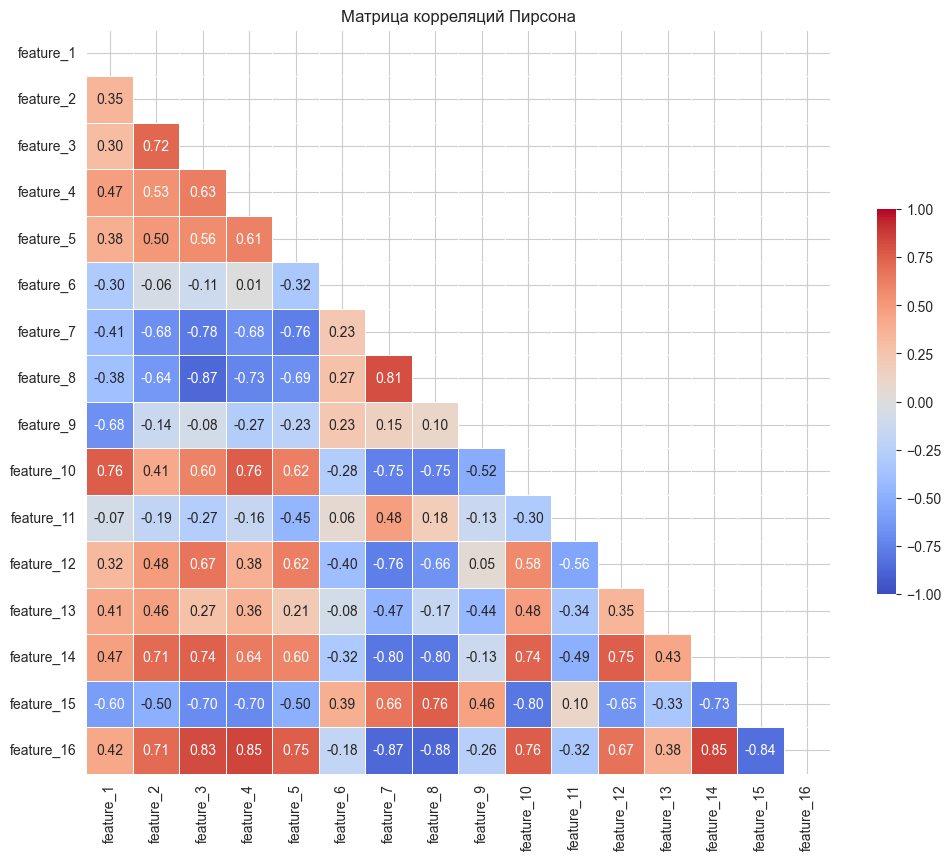

In [16]:
# 4. Корреляции
analyzer.plot_correlations()

### Распределения и связи первых 8 признаков

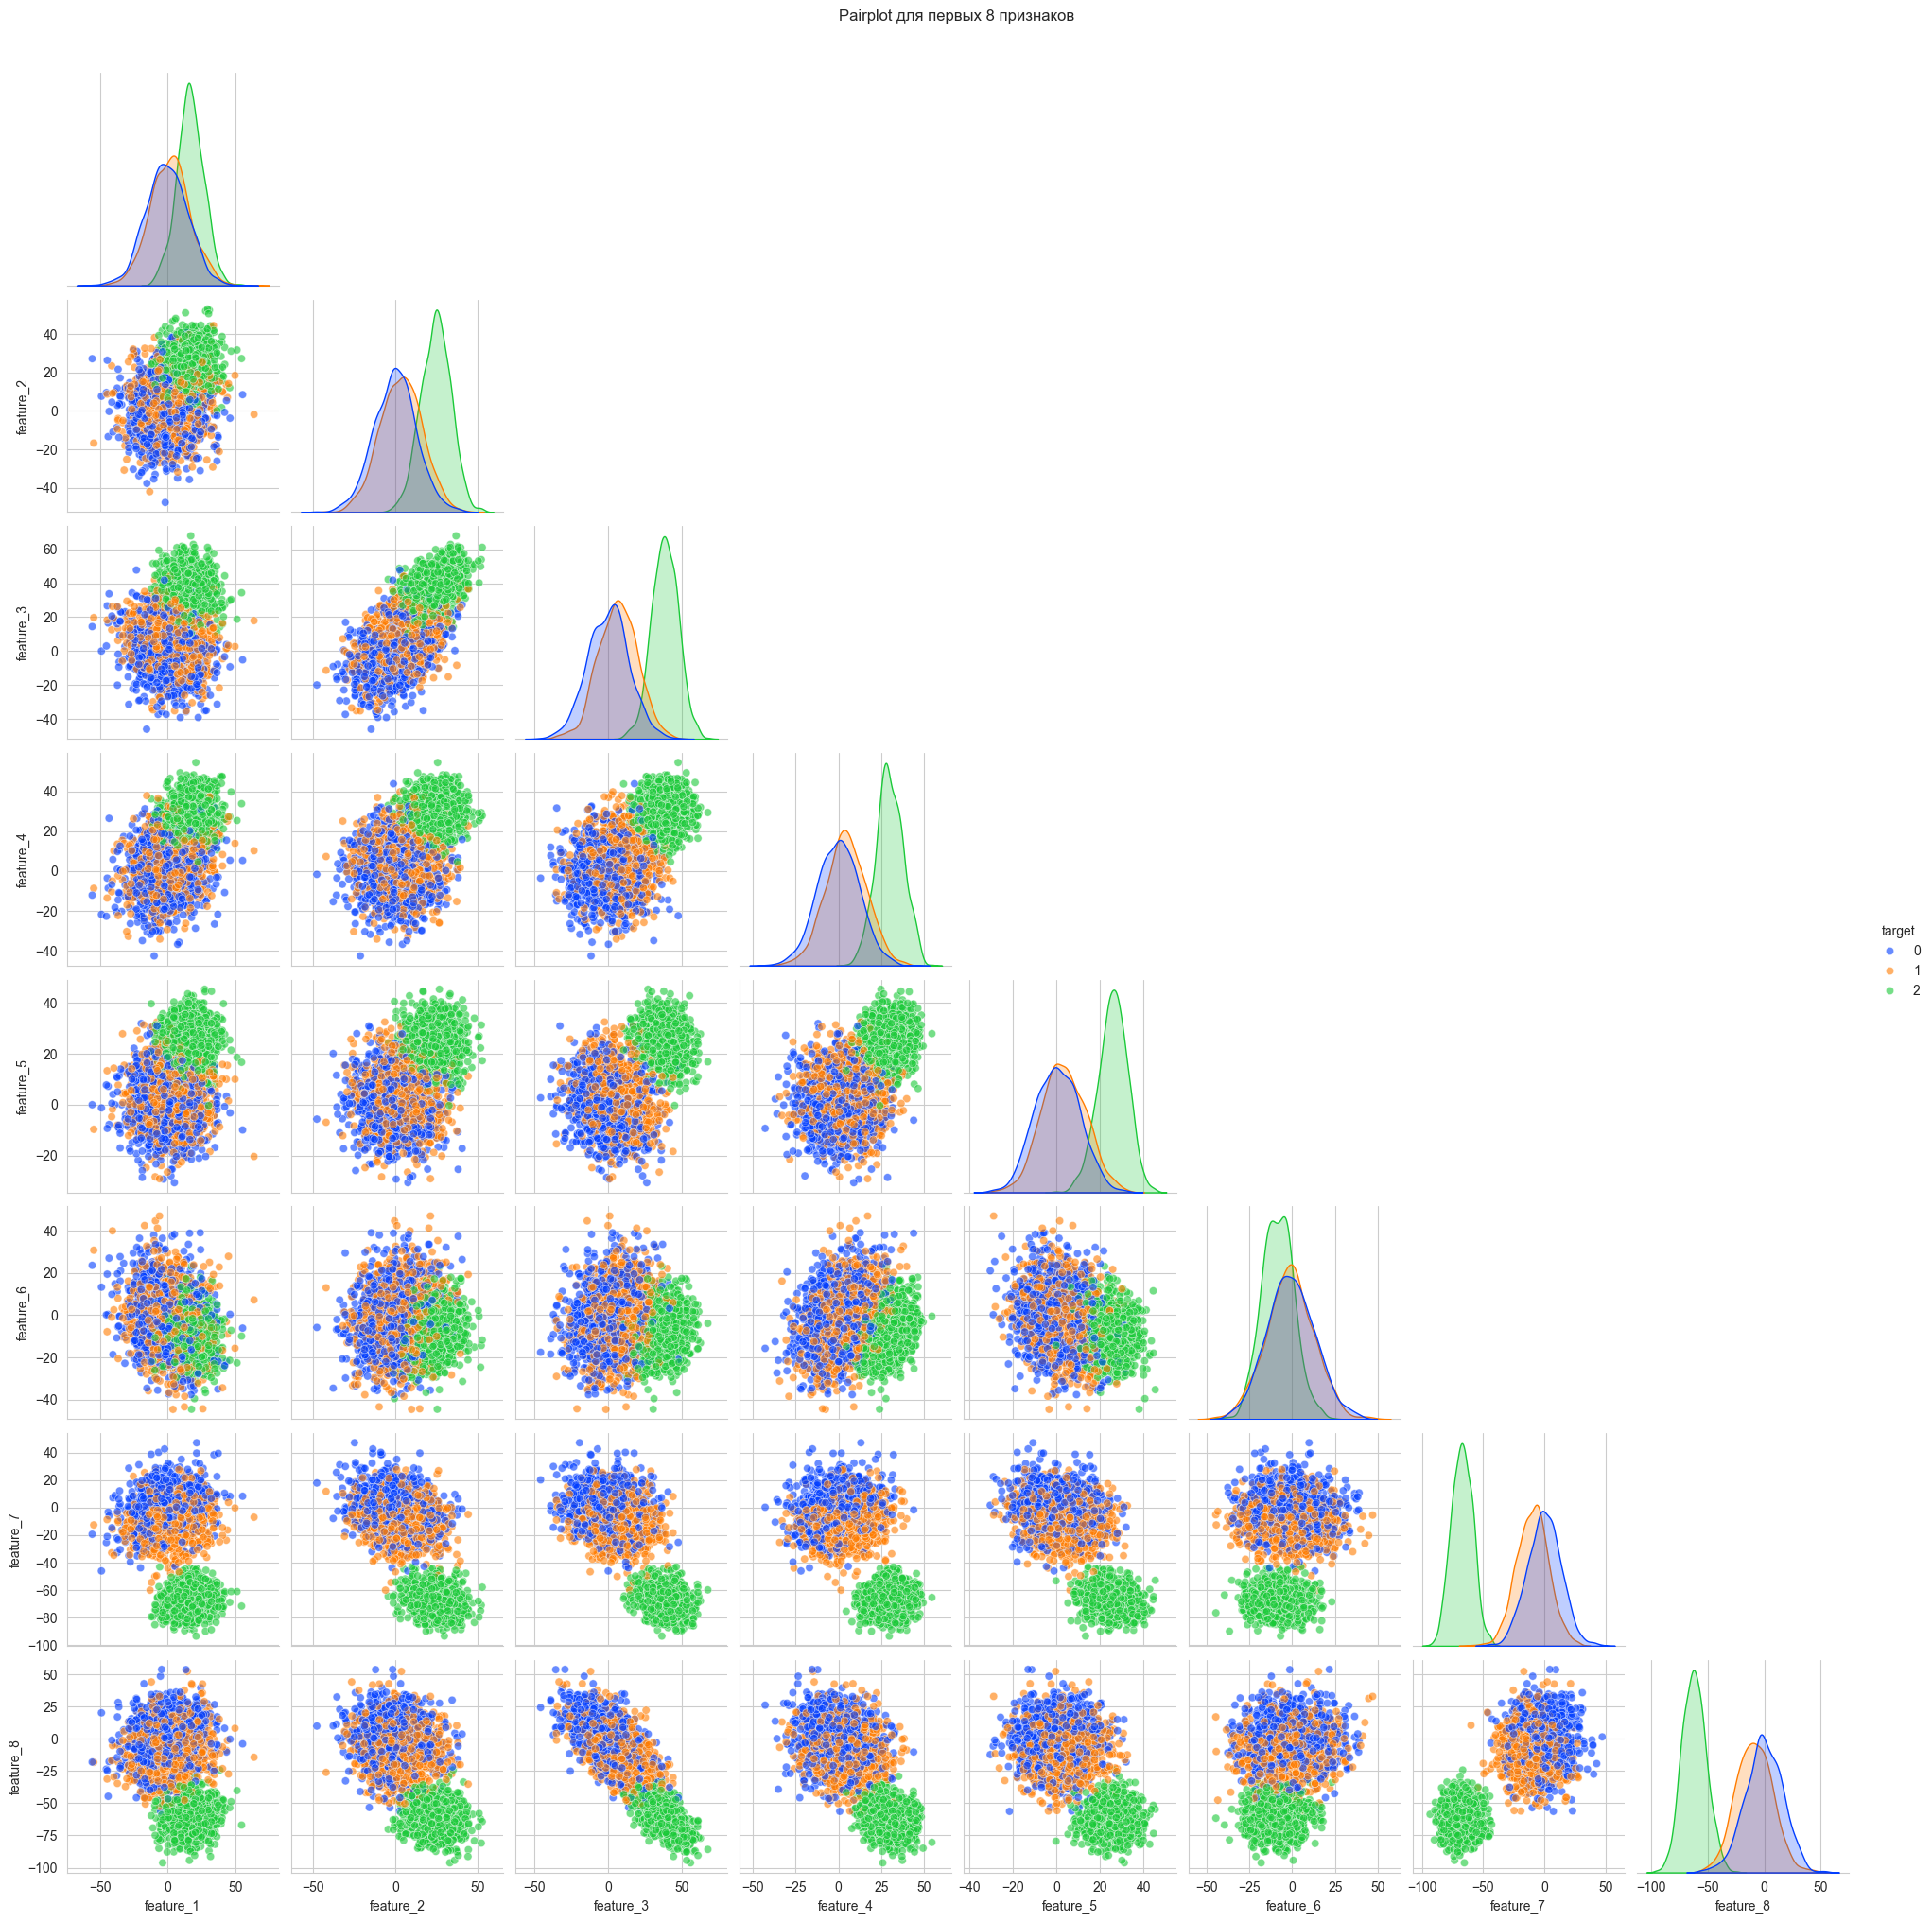

In [17]:
# 5. Визуализация распределений (первые 8 признаков для наглядности)
analyzer.plot_distributions(n_features=8)

In [18]:
# 1. Выбираем класс для дублирования. 
# В задании 1 мы делали перекрытие между классом 0 и 1.
# Выберем класс 1.
target_class_to_boost = 1 
multipliers_list = [2, 5, 10, 20, 50, 100, 1000, 10000] 

In [19]:
# 2. Генерация
imbalance_gen = ImbalanceGenerator()
imbalanced_datasets = imbalance_gen.create_imbalanced_versions(df1, target_class_to_boost, multipliers_list)

Исходный размер класса 1: 1000
Generated df2: Total rows = 4000, Target Class Rows = 2000
Generated df5: Total rows = 7000, Target Class Rows = 5000
Generated df10: Total rows = 12000, Target Class Rows = 10000
Generated df20: Total rows = 22000, Target Class Rows = 20000
Generated df50: Total rows = 52000, Target Class Rows = 50000
Generated df100: Total rows = 102000, Target Class Rows = 100000
Generated df1000: Total rows = 1002000, Target Class Rows = 1000000
Generated df10000: Total rows = 10002000, Target Class Rows = 10000000


In [20]:
# 3. Визуализация изменений
imbalance_gen.visualize_imbalance_dynamics(imbalanced_datasets, df1)

In [21]:
# Пара rkfccjd для анализа LDA и Центроидов
target_positive = 1
target_negative = 0

# Список множителей
multipliers_to_viz = [1, 5, 20, 100]

# Находим лучшие признаки для разделения классов 0 и 1
selected_features = get_best_features_pair(df1, target_negative, target_positive)

 Расчет координат для признаков: ['feature_16', 'feature_7']


### Таблица координат центров масс

,Multiplier,C_0 (Neg),C_1 (Pos),Segment Midpoint,Overall Mean
0,x1,"[-0.03, -0.35]","[10.72, -9.91]","[5.34, -5.13]","[5.34, -5.13]"
1,x5,"[-0.03, -0.35]","[10.72, -9.91]","[5.34, -5.13]","[8.93, -8.32]"
2,x20,"[-0.03, -0.35]","[10.72, -9.91]","[5.34, -5.13]","[10.21, -9.46]"
3,x100,"[-0.03, -0.35]","[10.72, -9.91]","[5.34, -5.13]","[10.61, -9.82]"


### Визуализация смещения общего центра масс

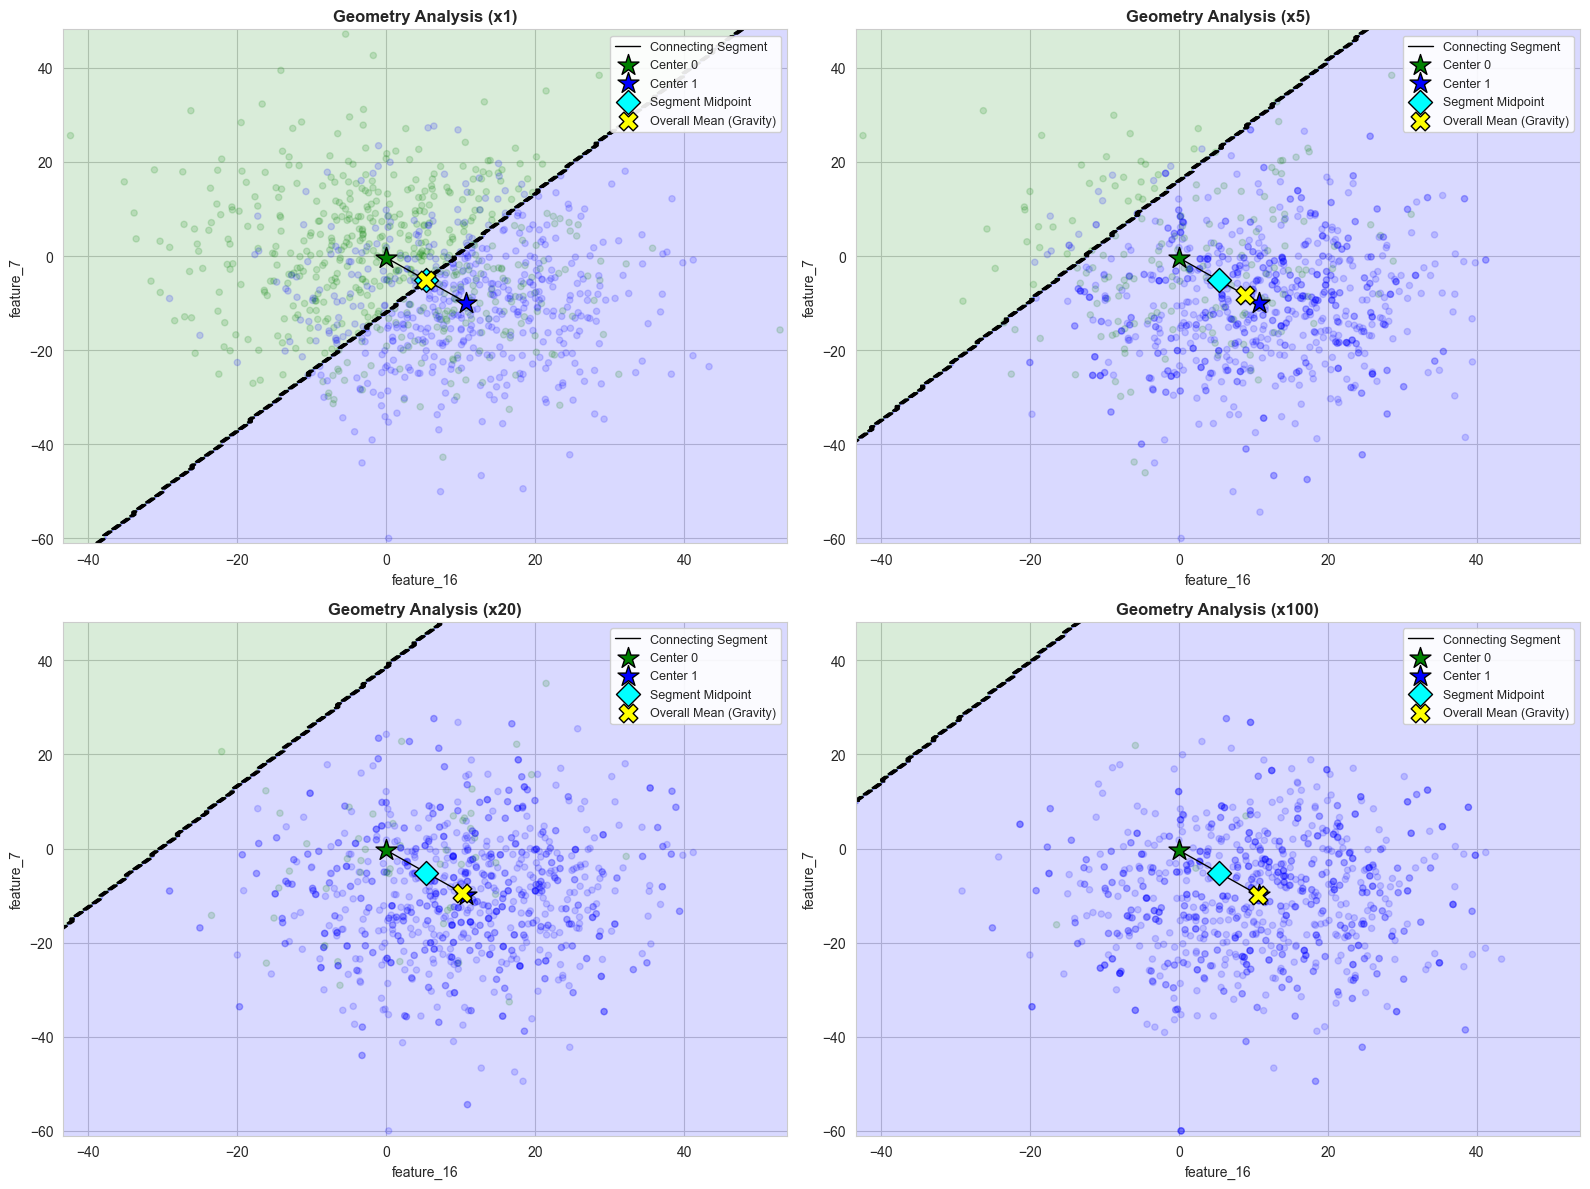

In [22]:

# Инициализация
reporter = CentroidReporter(selected_features, target_positive, target_negative)

# 1. Вывод таблицы
df_coords = reporter.get_coordinates_table(imbalanced_datasets, multipliers_to_viz)
display(Markdown("### Таблица координат центров масс"))
display(df_coords)

# 2. Визуализация
display(Markdown("### Визуализация смещения общего центра масс"))
reporter.visualize_geometry(imbalanced_datasets, multipliers_to_viz)

 Анализ LDA: feature_16 vs feature_7


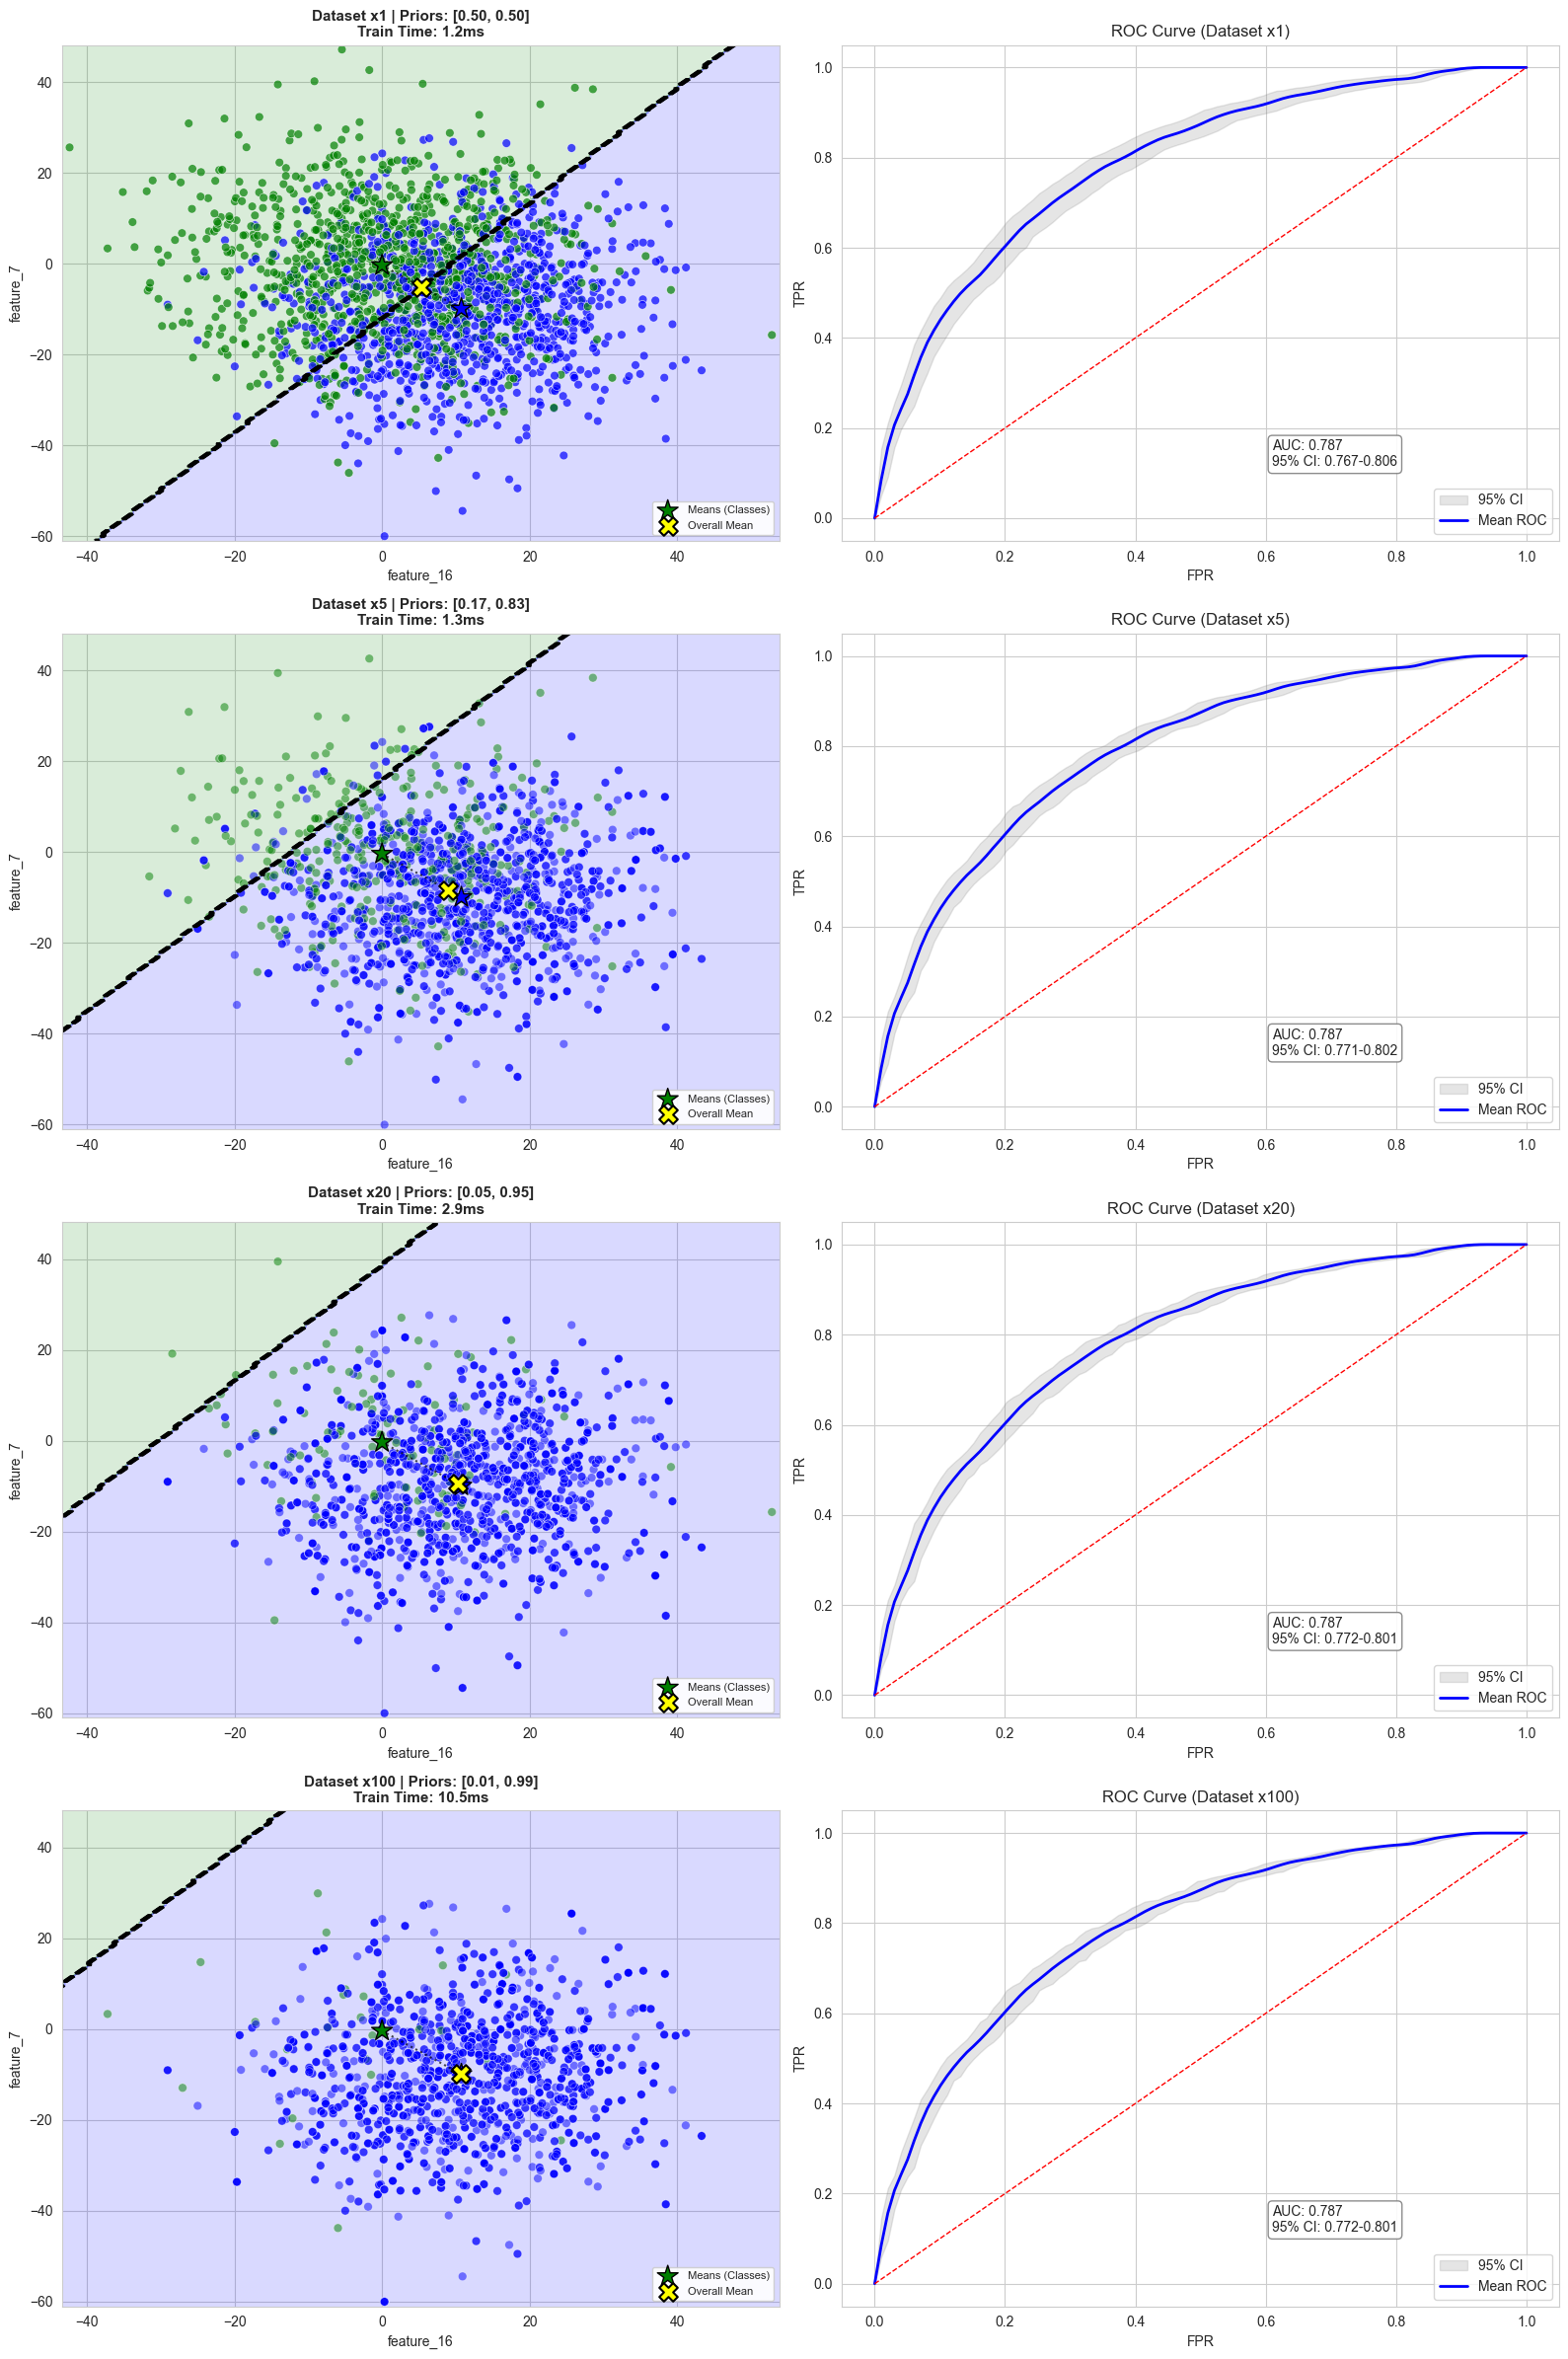

In [23]:
# 5. Инициализация и запуск LDA
viz_engine = LdaAdvancedViz(selected_features, target_positive, target_negative)
viz_engine.plot_dashboard(imbalanced_datasets, multipliers_to_viz)

Анализ Precision-Recall: feature_16 vs feature_7


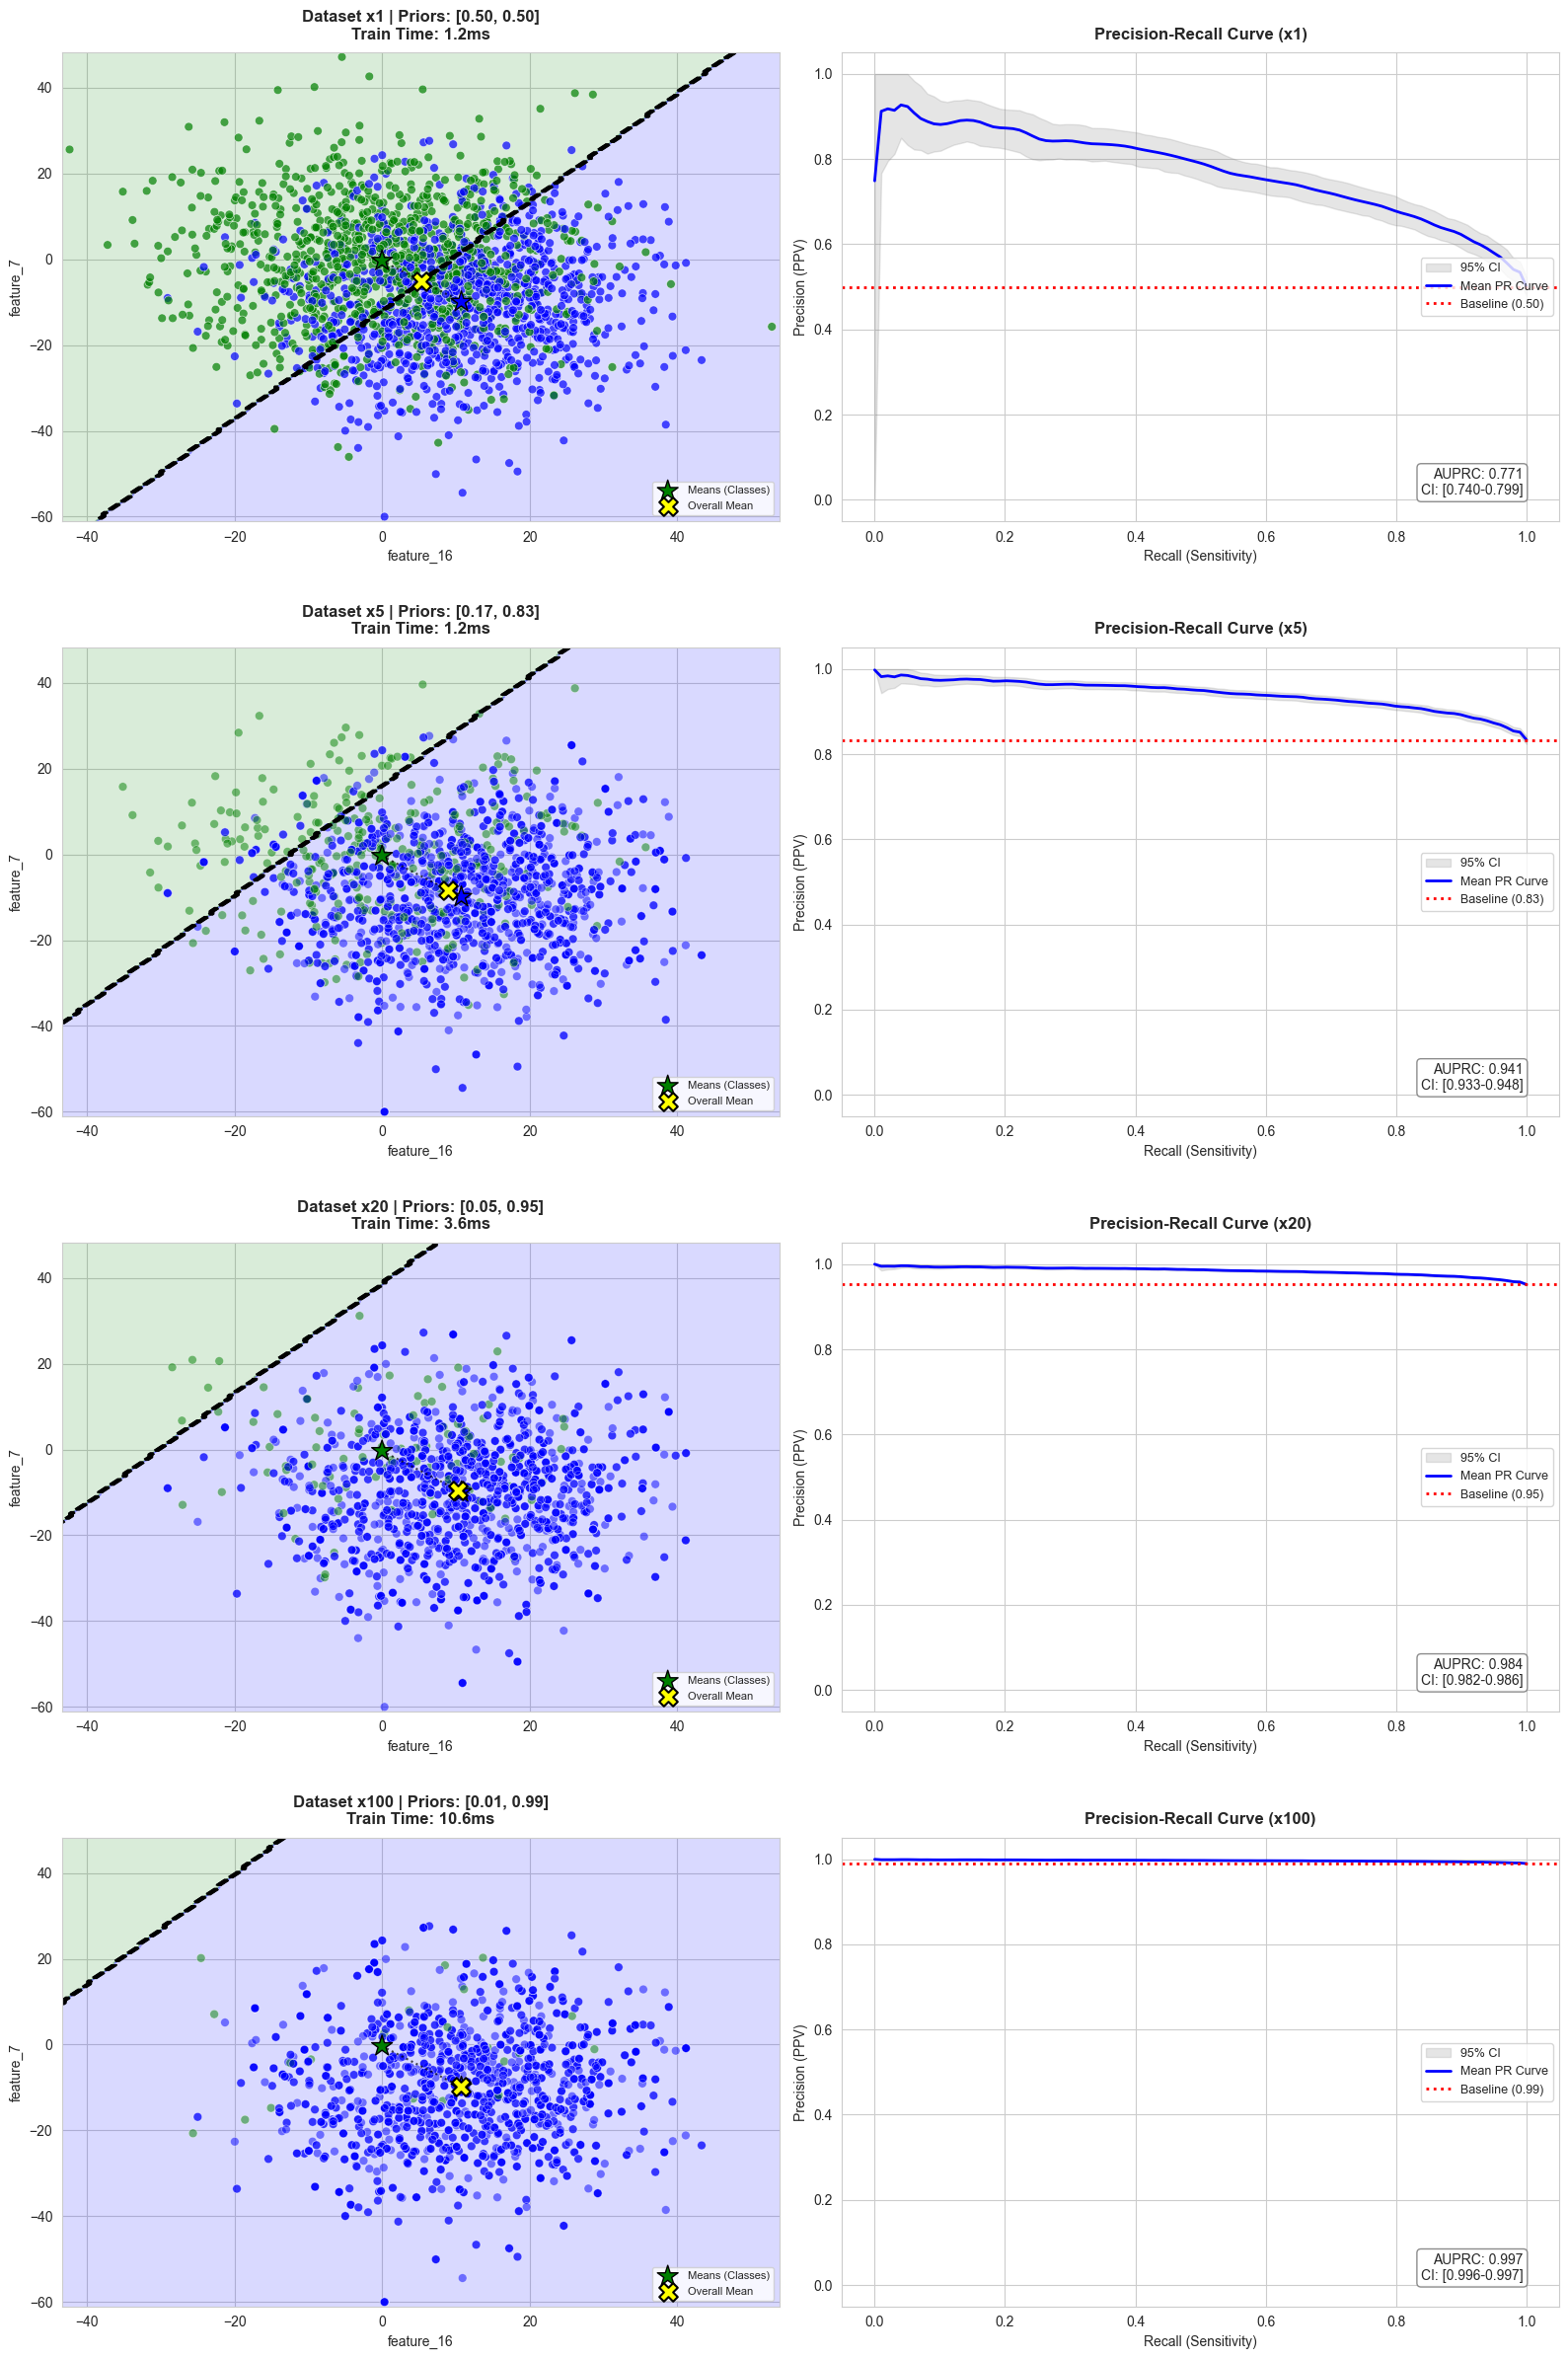

In [24]:
pr_viz = LdaPrViz(selected_features, target_positive, target_negative)
pr_viz.plot_dashboard(imbalanced_datasets, multipliers_to_viz)

 Анализ LDA: feature_16 vs feature_7


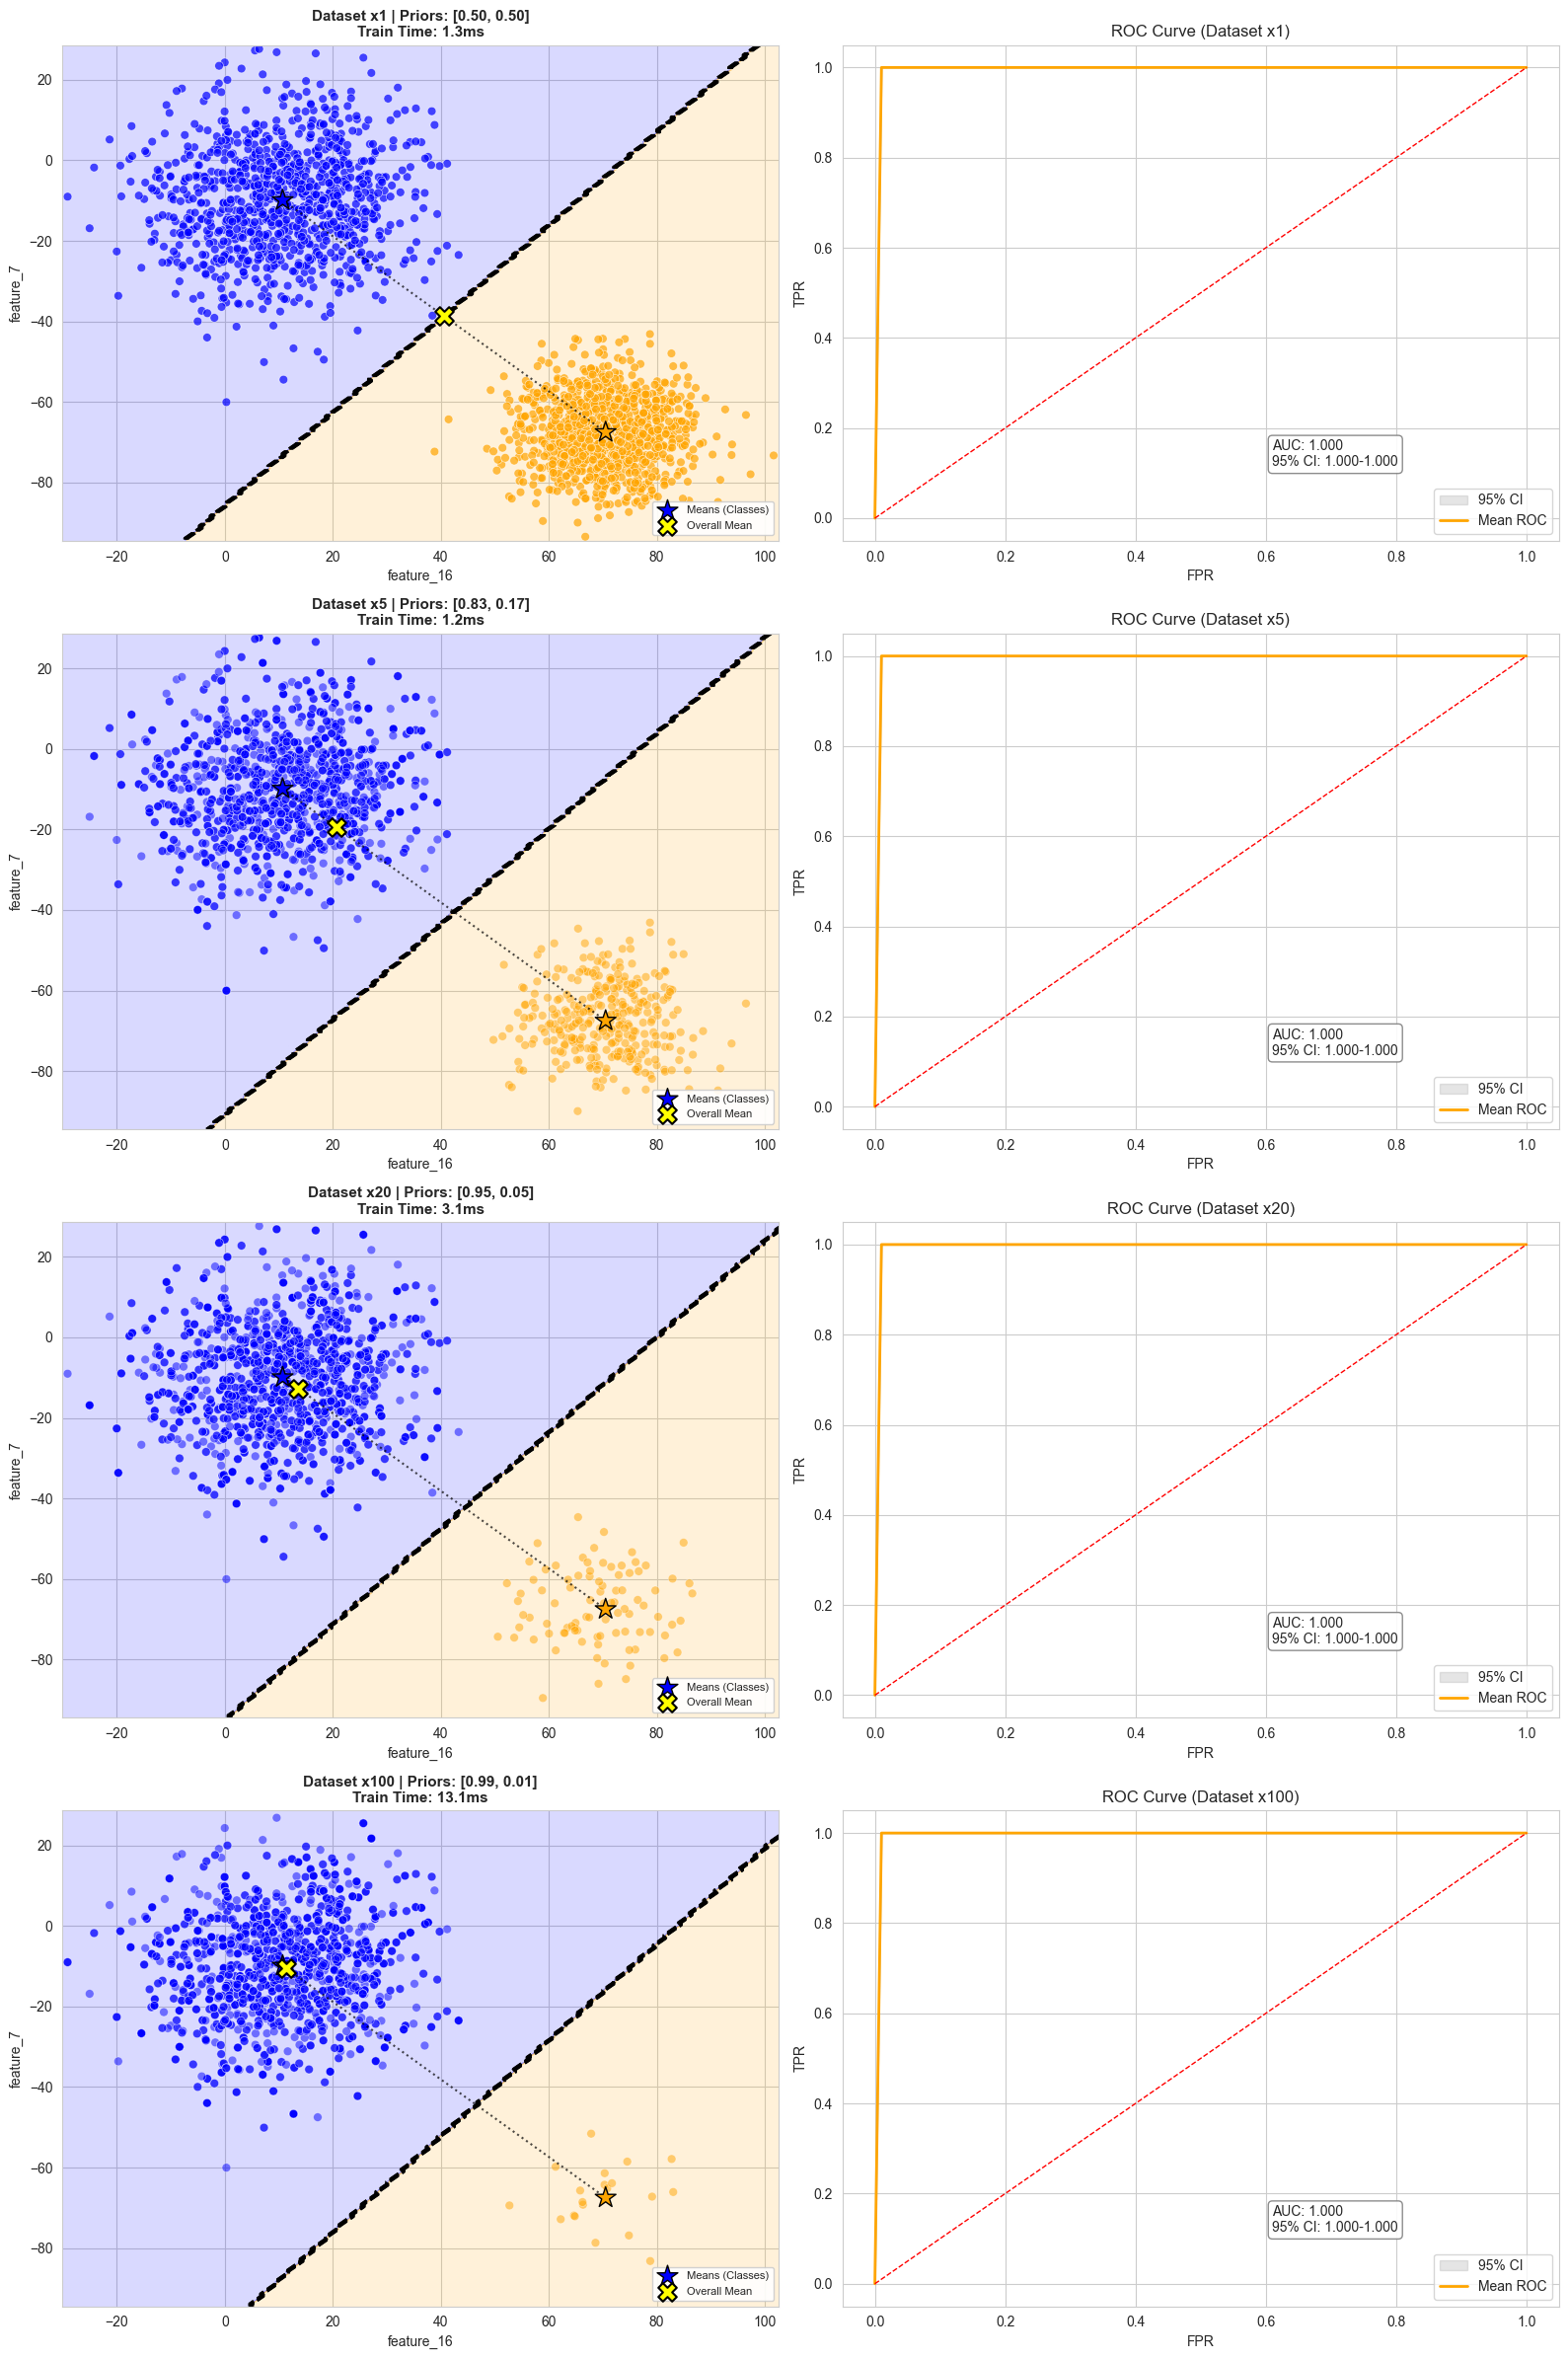

In [25]:
target_pos_new = 2
target_neg_new = 1
    
# Инициализация визуализатора с новыми классами
viz_engine_easy = LdaAdvancedViz(selected_features, target_pos_new, target_neg_new)

# Построение графиков
viz_engine_easy.plot_dashboard(imbalanced_datasets, multipliers_to_viz)

Запуск CV анализа. Признаки: ['feature_16', 'feature_7']
   Классы: 0 (Neg) vs 1 (Pos, цвет=blue)


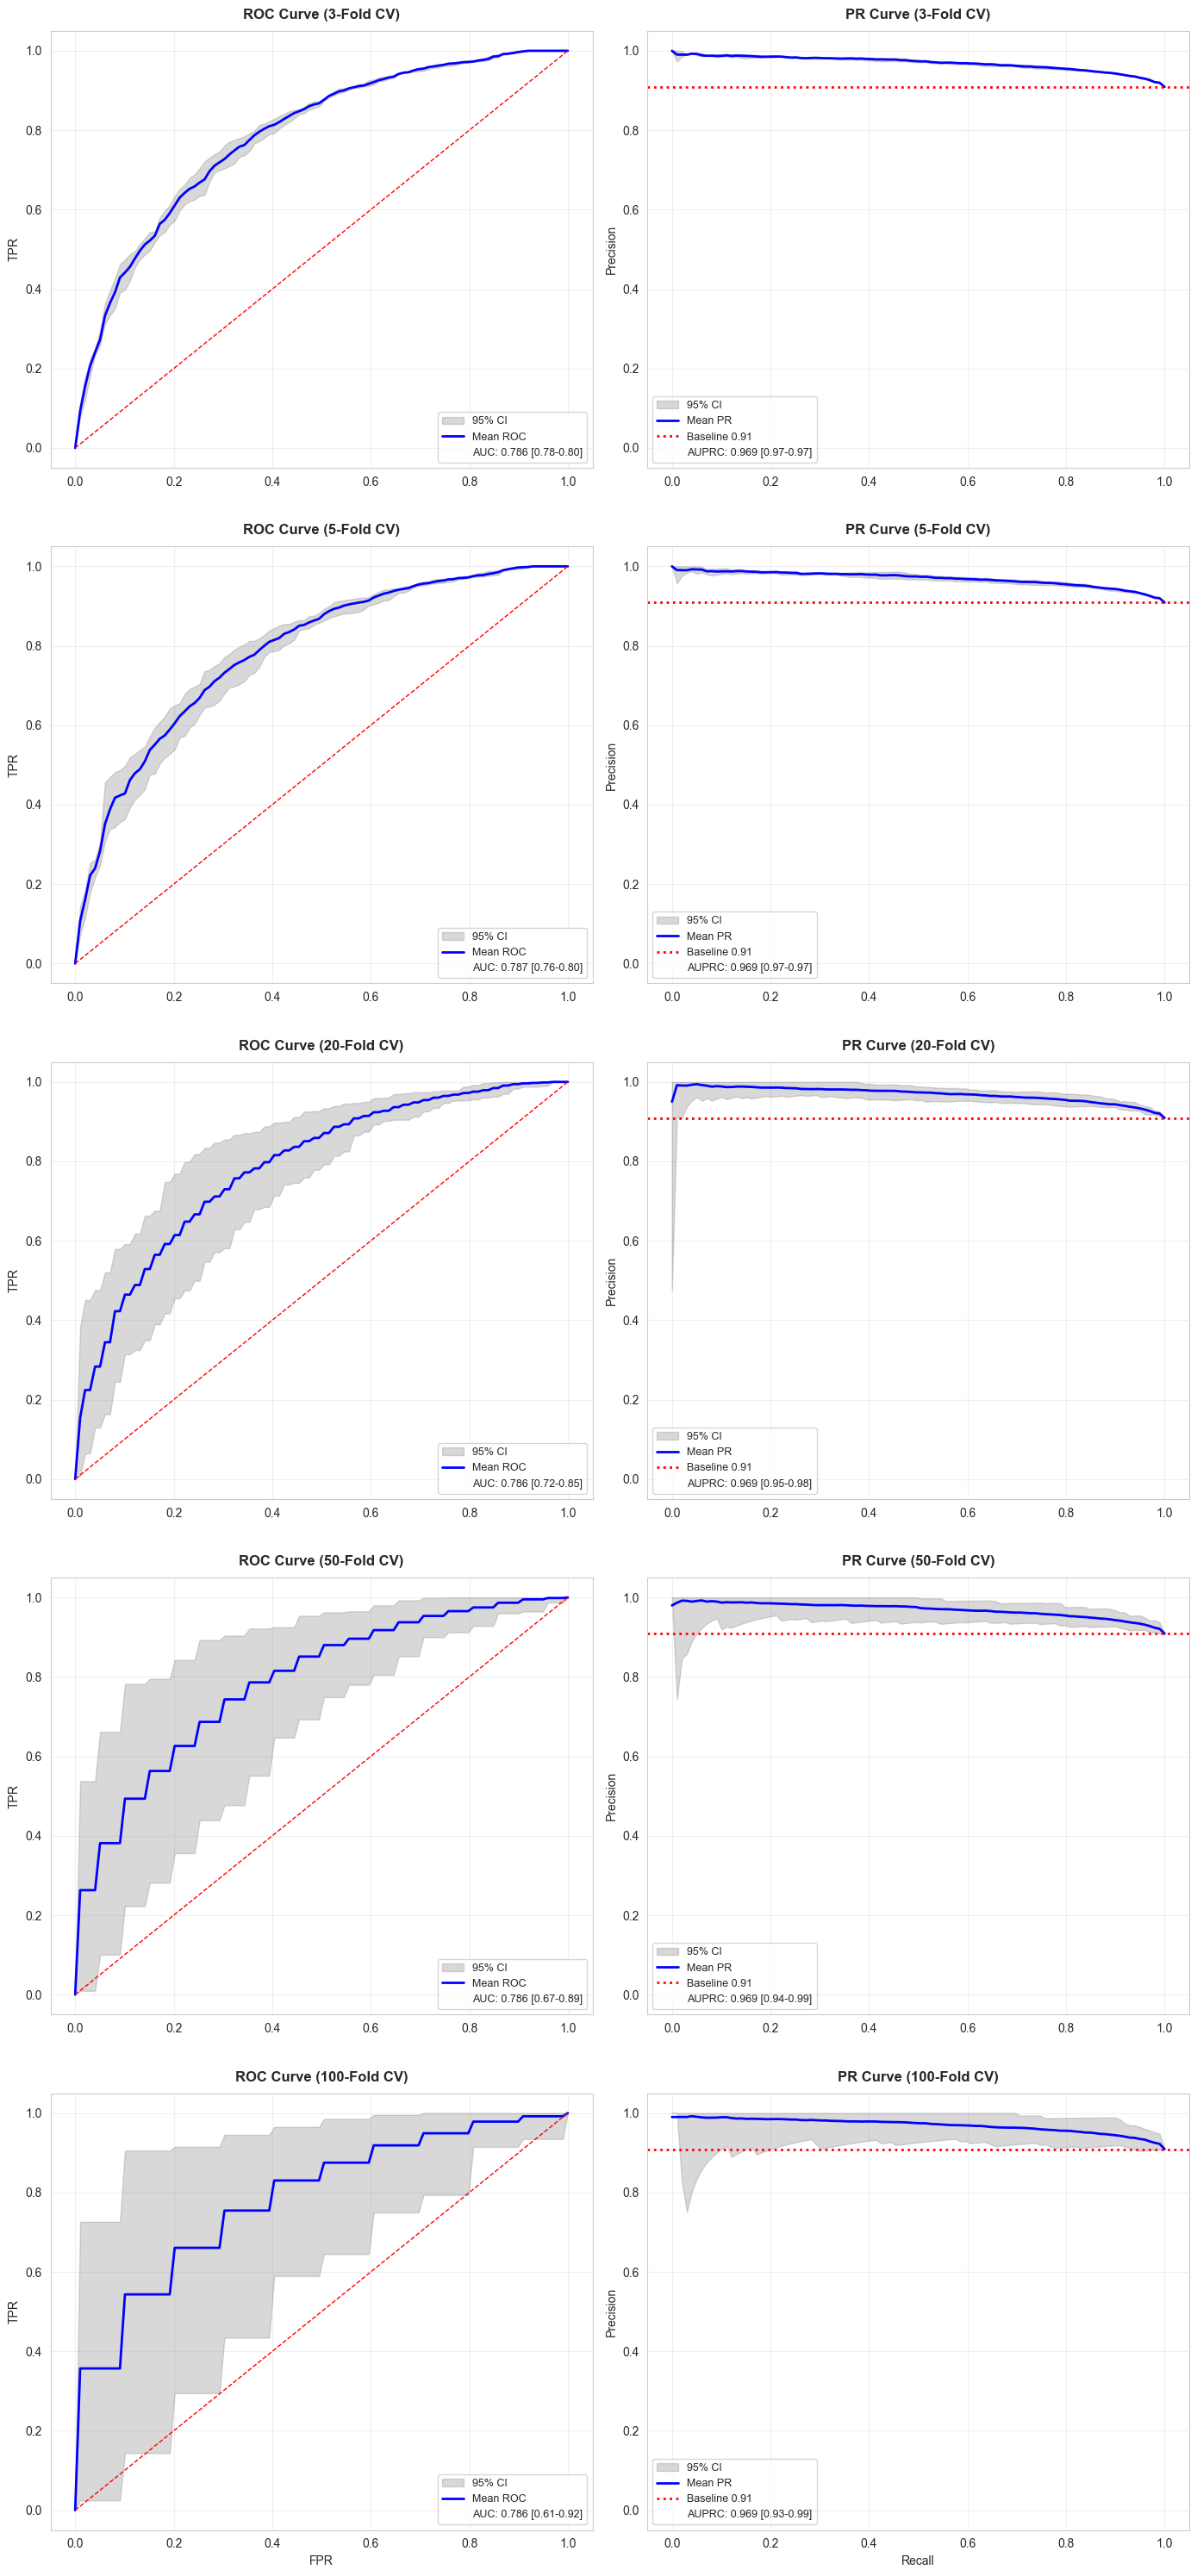

In [26]:
target_dataset_key = 10
        
cv_viz = CvReporter(selected_features, target_pos=1, target_neg=0)
cv_viz.plot_cv_analysis(imbalanced_datasets[target_dataset_key], [3, 5, 20, 50, 100])

Анализ размерности: 0 (Neg) vs 1 (Pos)


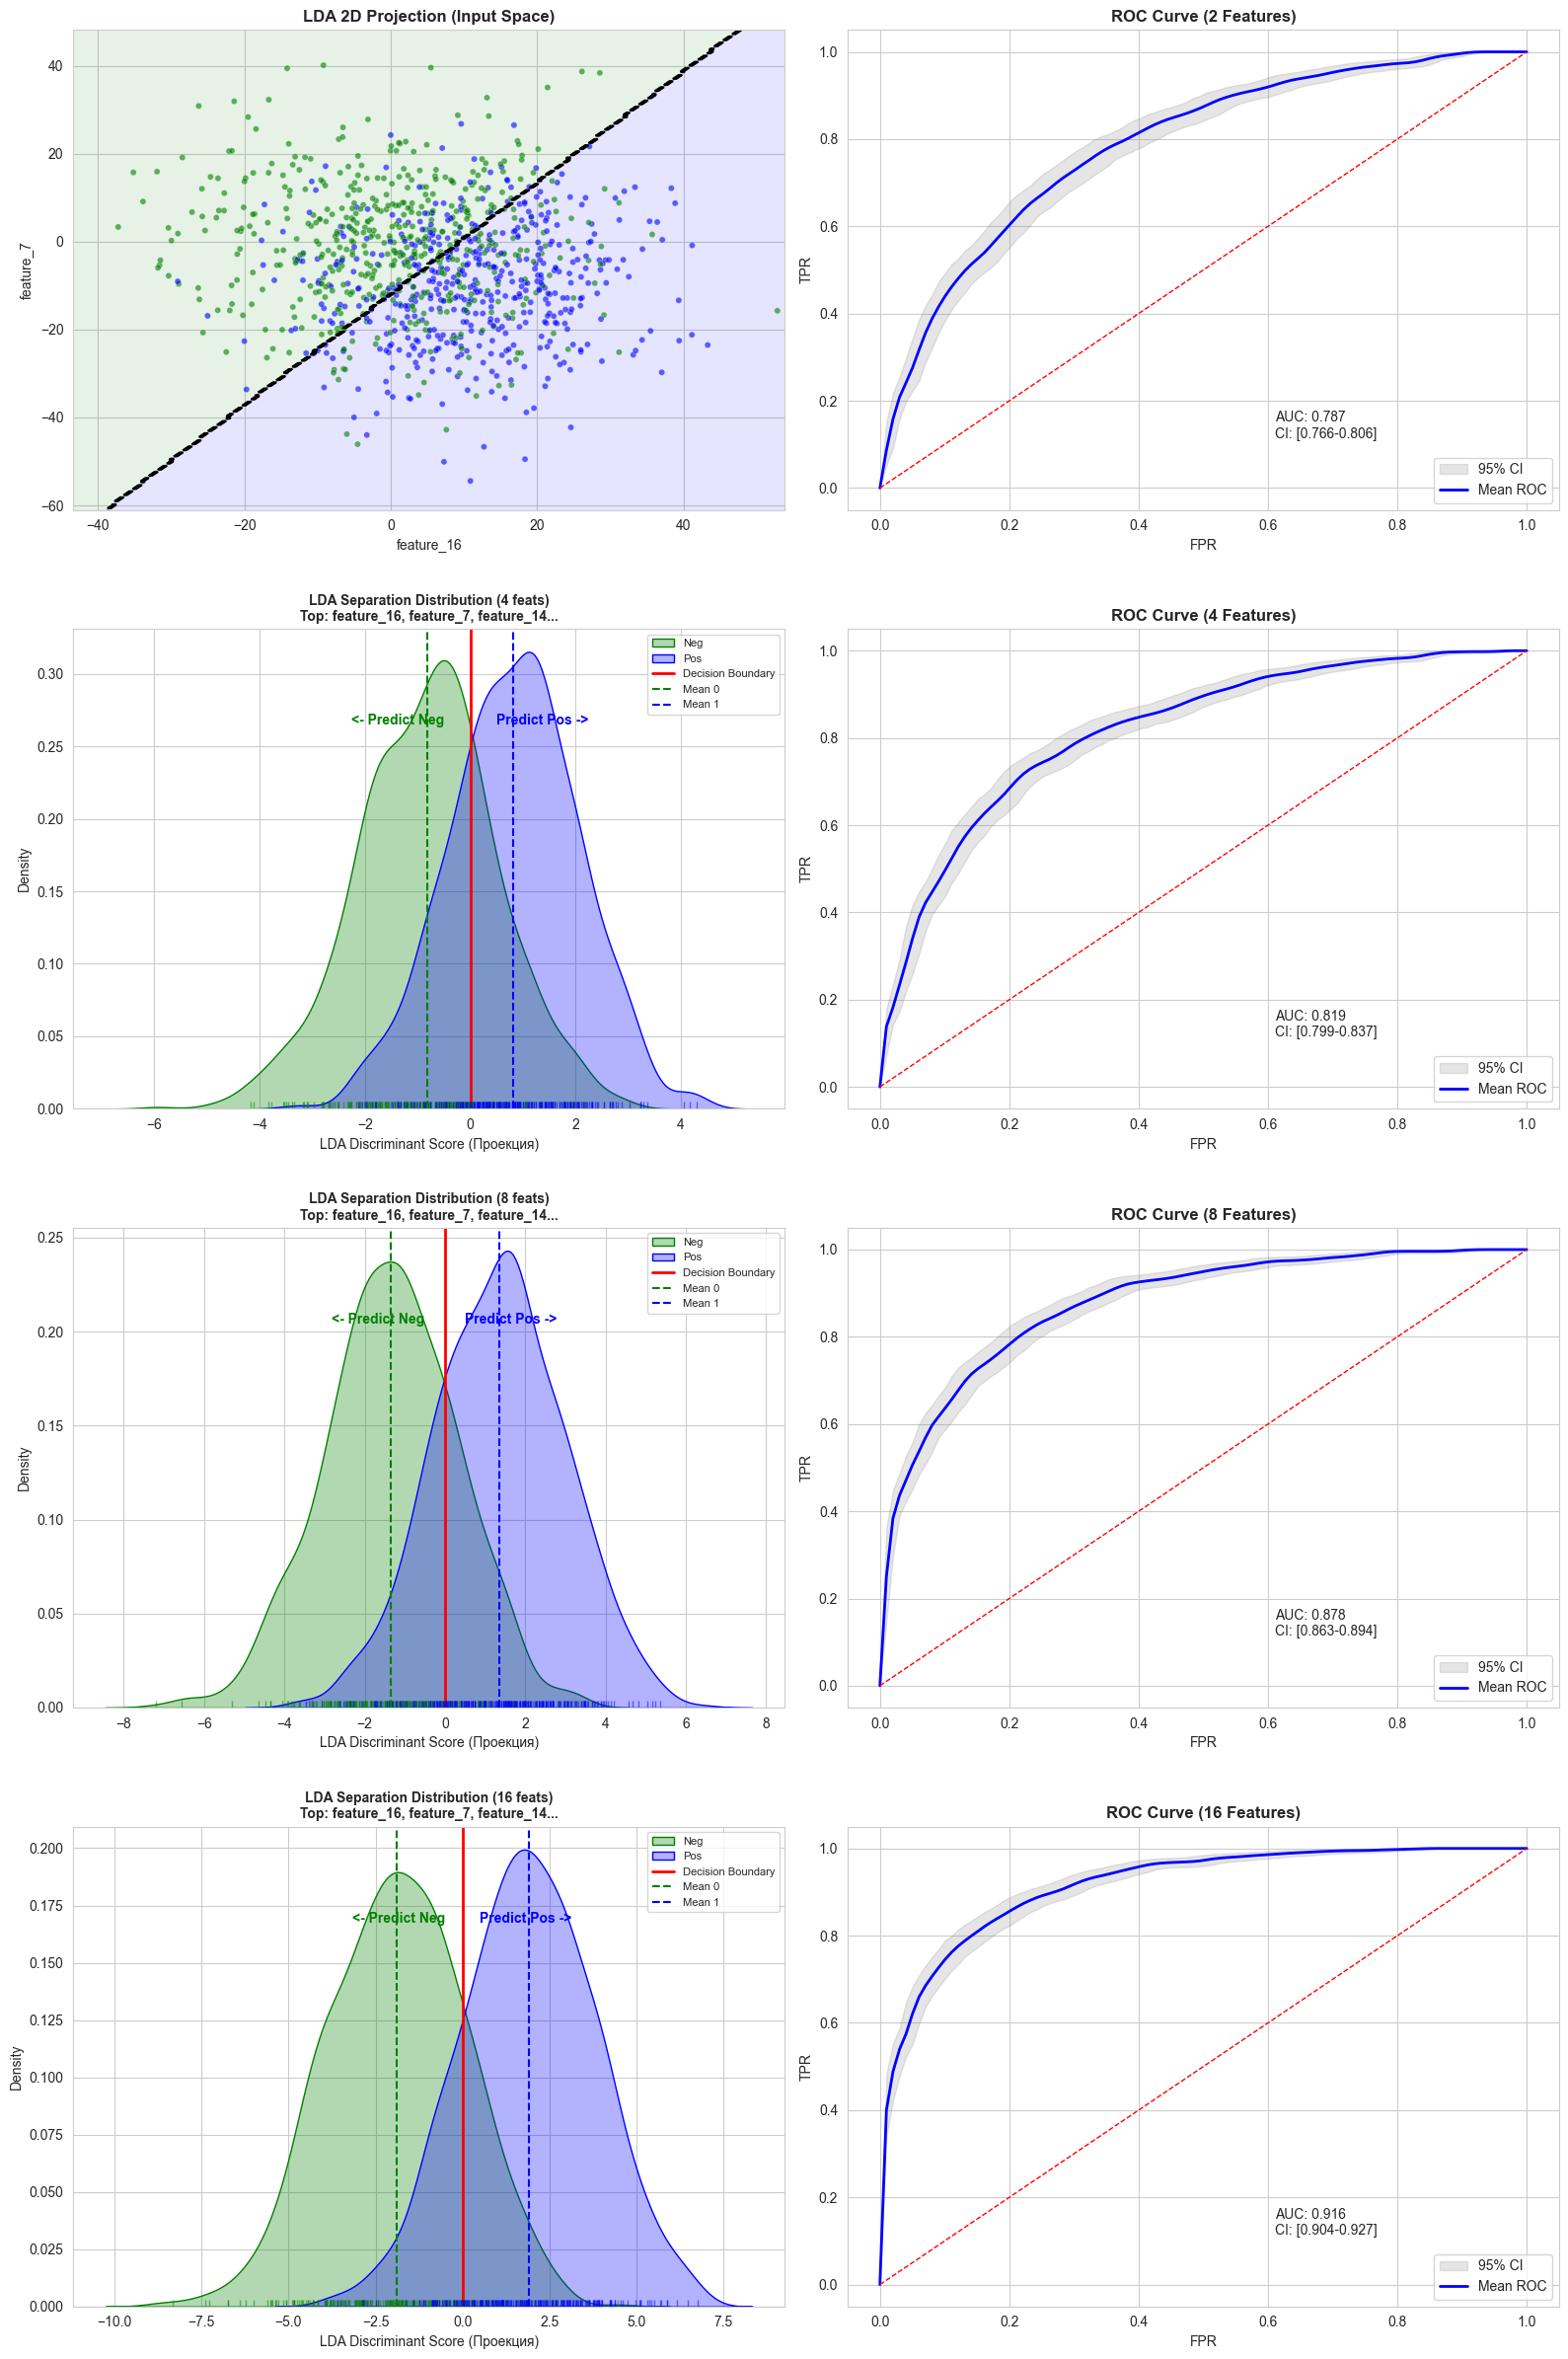

In [27]:

target_df = imbalanced_datasets[1] 
viz = LdaDimViz(target_pos=1, target_neg=0)
viz.plot_analysis(target_df, [2, 4, 8, 16])

In [28]:
# 1 vs 0 (Сложная пара)
svm_viz = SvmInteractiveViz(selected_features, target_pos=1, target_neg=2)

svm_viz.plot_dashboard(imbalanced_datasets, [1, 5, 20, 100])

 Запуск SVM (Linear) для ['feature_16', 'feature_7']
